# PEN Wavelength Shifter Characterisation in DWARF

## Physics context

Liquid argon scintillates at 128 nm — deep in the vacuum ultraviolet, where most photon sensors have no sensitivity and standard optical components absorb the light. Wavelength-shifting materials solve this by absorbing VUV photons and re-emitting them at visible wavelengths where conventional PMTs work efficiently.

PEN (polyethylene naphthalate) is a promising candidate to replace the current standard material TPB (tetraphenyl butadiene). It offers better mechanical robustness, easier large-scale integration, and simpler handling — important advantages for tonne-scale detectors like DUNE that need to cover hundreds of square metres of surface.

The key question is stability: does PEN maintain its wavelength-shifting efficiency under continuous VUV exposure and cryogenic conditions over timescales relevant to long-running experiments?

## Experiment

The DWARF detector is a 2-tonne liquid argon dewar at CERN. PEN foils line a hexagonal cage of approximately 1 metre vertical length inside the dewar. A single PMT — blind to VUV light — is mounted to view the cage. It detects only the visible photons re-emitted by the PEN after absorbing the 128 nm argon scintillation, making its signal a direct measure of PEN wavelength-shifting performance.

<img src="dwarf.png" width="600px">

Two radiation sources drive argon scintillation and are used to monitor PEN stability:

- **Am-241 alpha source** — movable along the cage, allowing spatial characterisation of light yield uniformity across different PEN foil positions. Alphas have very short range in liquid argon so the energy deposition is local and well-defined, producing a clean, reproducible scintillation signal at each position.
- **Cosmic muons** — traverse the full active volume, producing scintillation uniformly along their path and providing an independent cross-check of the light yield integrated over the entire detector.

## Goal

Demonstrate stable PEN light yield over 12 days of continuous cryogenic operation, and characterise uniformity across different alpha source positions — directly relevant to validating PEN for large-scale use in next-generation liquid argon detectors.

## 1. Setup and Imports

In [12]:
import os
import numpy as np
from numba import jit
import uproot
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from lmfit import Model, Parameters
from uncertainties import unumpy as unp

# Custom oscilloscope waveform reader — readTrc.py must be in the same directory
from readTrc import Trc

# Style
plt.style.use('sty.mplstyle')
mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble'] = r'\usepackage{upgreek}'

## 2. Fitting Functions

A small set of model functions used throughout the analysis for fitting spectra, 
pulse shapes, and calibration data.

In [2]:
def gaussian(x, amp, cen, wid):
    """Simple Gaussian — used for fitting the alpha charge spectrum."""
    return amp * np.exp(-(x - cen)**2 / (2 * wid**2))


def fit_gaussian_line(x, a, b, c, d, e):
    """
    Gaussian + linear background.
    Used for fitting the muon charge spectrum from oscilloscope data
    where a slowly varying background sits beneath the signal peak.
    Parameters: a = amplitude, b = mean, c = sigma, d = slope, e = intercept.
    """
    return [a * np.exp(-(x[k] - b)**2 / (2 * c**2)) + d * x[k] + e
            for k in range(len(x))]


def decay(t, N, tau, C):
    """
    Exponential decay with constant offset.
    Used to fit the late light component of the muon pulse shape
    and extract the argon triplet lifetime.
    """
    return N * np.exp(-t / tau) + C


def constant(t, a):
    """Flat line — used to fit the pre-trigger baseline of the pulse shape."""
    return [a for _ in t]

## 3. Oscilloscope Processing Pipeline

The oscilloscope records PMT waveforms triggered on cosmic muon events. Four functions process these raw waveforms into per-event charge and prompt light fraction quantities used in the muon analysis.

The processing chain is:
1. Estimate the baseline of each waveform (`baseline_estimate`)
2. Apply baseline estimation to all waveforms in a run (`find_baseline`)
3. Extract charge and fprompt from a single waveform (`analyse_oscilloscope`)
4. Run the full pipeline on a directory of waveform files (`run_oscilloscope`)

In [3]:
@jit(nopython=True)
def baseline_estimate(wf):
    """
    Estimate the baseline of a single PMT waveform by iteratively
    removing upward outliers until only baseline samples remain.
    Falls back to taking the median of the first samples for high-occupancy
    or pileup events where the iterative method would fail.
    """
    trace = np.copy(wf)
    trace_new = np.zeros_like(trace)

    # For longer traces, enough pre-trigger samples exist for a direct estimate
    if 2000 < trace_new.size < 4000:
        return np.median(trace[:400]), np.std(trace[:400])
    if trace_new.size > 4000:
        return np.median(trace[:800]), np.std(trace[:800])

    # Iterative outlier removal for shorter traces
    for i in range(5):
        wf_med = np.median(trace)
        wf_rms = np.std(trace)
        k = 0
        for j in range(trace.size):
            if trace[j] > wf_med - 2 * wf_rms:
                trace_new[k] = trace[j]
                k += 1
        trace = trace_new[:k]

    # If too few samples remain, the event is crowded — use first samples
    if len(trace) < 750:
        return np.median(wf[:150]), np.std(wf[:150])

    return np.median(trace), np.std(trace)


def find_baseline(wf_array):
    """
    Apply baseline_estimate to all waveforms in a run.
    Returns arrays of baseline values and RMS noise per waveform.
    """
    n = len(wf_array)
    base = np.zeros(n)
    rms  = np.zeros(n)
    print(f"Estimating baseline for {n} waveforms...")
    for i in range(n):
        base[i], rms[i] = baseline_estimate(wf_array[i])
    print("Baseline estimation complete")
    return base, rms


def analyse_oscilloscope(trace_original, baseline, plot=False):
    """
    Extract charge and prompt light fraction from a single PMT waveform.

    The waveform is baseline-subtracted, then integrated in three windows
    relative to the trigger centre:
    - Prompt window: captures the fast scintillation component
    - Total window: captures prompt + late light
    - Late window: starts 1 µs after trigger, captures triplet component only

    fprompt = Q_prompt / Q_total — used to separate muon events from noise.
    """
    trace = baseline - trace_original

    # Integration windows depend on waveform length (sampling rate)
    if len(trace_original) < 4000:
        start, end = 400, 800
        left_boundary      = -25
        right_boundary_prompt = 38
        right_boundary_total  = 1250
        one_micro = 250
    else:
        start, end = 800, 1600
        left_boundary      = -50
        right_boundary_prompt = 75
        right_boundary_total  = 2500
        one_micro = 500

    trigger_centre = np.argmax(trace[start:end]) + start

    qprompt = np.sum(trace[trigger_centre + left_boundary:
                           trigger_centre + right_boundary_prompt])
    qt      = np.sum(trace[trigger_centre + left_boundary:
                           trigger_centre + right_boundary_total])
    qlate   = np.sum(trace[trigger_centre + left_boundary + one_micro:
                           trigger_centre + right_boundary_total])

    fp = qprompt / qt if qt > 0 else -1

    if plot:
        x_val = np.linspace(0, 10, len(trace_original))
        plt.figure(figsize=(12, 8))
        plt.plot(x_val, trace)
        plt.axvline(x_val[trigger_centre + left_boundary + one_micro],
                    label='Late light start')
        plt.axvline(x_val[trigger_centre + right_boundary_total],
                    label='Integration end')
        plt.xlabel(r'Time ($\upmu$s)')
        plt.ylabel('Voltage (mV)')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return qlate, fp, trigger_centre


def run_oscilloscope(dir_path, plot=False):
    """
    Run the full oscilloscope processing pipeline on a directory of .trc files.
    Reads all waveforms, estimates baselines, extracts per-event charge and
    fprompt, and accumulates the average late light histogram for lifetime fitting.

    Returns
    -------
    all_qt         : list of total charge per event [a.u.]
    all_fp         : list of fprompt per event
    hist_charge    : accumulated late light histogram for triplet lifetime fit
    baseline, rms  : per-waveform baseline and noise estimates
    """
    trc = Trc()
    wf  = []
    issue_count = 0

    for root, dirs, files in os.walk(dir_path):
        for file in sorted(files):
            if file.endswith('.trc') and ('C1R' in file or 'PMT' in file):
                try:
                    _, datY, _ = trc.open(os.path.join(root, file))
                    wf.append(datY * 1000)
                except Exception:
                    issue_count += 1

    print(f"Loaded {len(wf)} waveforms ({issue_count} failed)")

    baseline, rms = find_baseline(wf)

    # Integration windows for the late light histogram
    if len(wf[0]) < 4000:
        start_E, end_E   = 90, 135
        micro_2_index    = 500
        hist_charge      = np.zeros(len(wf[0]) + 250)
    else:
        start_E, end_E   = 180, 270
        micro_2_index    = 1000
        hist_charge      = np.zeros(len(wf[0]) + 500)

    all_qt, all_fp = [], []
    count = 0

    for j in range(len(wf)):
        qt, fp, trigger = analyse_oscilloscope(wf[j], baseline[j])
        all_qt.append(qt / 1000)
        all_fp.append(fp)

        # Accumulate late light histogram for events in the muon charge window
        # with physical fprompt — used for triplet lifetime measurement
        if start_E < qt / 1000 < end_E and 0.2 < fp < 0.5:
            count += 1
            index_to_move = micro_2_index - trigger
            for k in range(len(wf[j])):
                hist_charge[k - index_to_move] += baseline[j] - wf[j][k]

    print(f"Muon candidates selected for lifetime histogram: {count}")
    return all_qt, all_fp, hist_charge, baseline, rms

## 4. DAQ Event Reading

The main DAQ system records alpha source events. Processed ROOT files are read with `uproot` and converted to per-event Python lists. Three functions handle reading at different levels of granularity — single run, all runs, and day-grouped runs — and a fourth fits the resulting alpha charge spectrum.

The key quantity extracted per event is the **trail alpha charge** — the total charge of the alpha-induced scintillation signal normalised to the single photoelectron (SPE) response, giving light yield in units of photoelectrons (PE).

In [4]:
@jit
def read_events(events, spe):
    """
    Extract per-event quantities from a ROOT tree array.
    Normalises all charge quantities by the SPE value to convert
    raw ADC charge to photoelectrons.

    The trail alpha selection requires:
    - exactly one identified alpha candidate in the trailing window
    - useful_for_trail_analysis flag set by the DAQ processing

    Returns
    -------
    trig_qt    : trigger window total charge [PE]
    trig_fp    : trigger window fprompt
    trail_fp   : trail alpha fprompt
    trail_qt   : trail alpha total charge [PE]
    ratio_charge_trail_alpha : ratio of secondary to primary peak charge
                               — used to reject events with nearby activity
    prelight   : pre-trigger charge [PE]
    """
    trig_qt, trig_fp   = [], []
    trail_fp, trail_qt = [], []
    ratio_charge_trail_alpha = []
    prelight = []

    for index in range(len(events)):
        peaks_centre = events['Peaks_centre'][index]
        peaks_charge = events['Peaks_charge'][index]

        trig_qt.append(events['trigger_qt'][index] / spe)
        trig_fp.append(events['trigger_fp'][index])

        if (events['useful_for_trail_analysis'][index] and
                len(events['tail_alpha'][index]) == 1):

            prelight.append(events['q_pretrigger_list'][index][0] / spe)
            trail_qt.append(events['qt_list'][index][0] / spe)
            trail_fp.append(events['qp_list'][index][0] /
                            events['qt_list'][index][0])

            alpha_index = events['tail_alpha'][index][0]
            max_charge, prompt_peak_charge = -1, -1

            for l in range(len(peaks_centre)):
                if peaks_centre[l] == alpha_index:
                    prompt_peak_charge = peaks_charge[l]
                if 0 < peaks_centre[l] - alpha_index < 200:
                    if peaks_charge[l] > max_charge:
                        max_charge = peaks_charge[l]

            ratio_charge_trail_alpha.append(max_charge / prompt_peak_charge)

    return trig_qt, trig_fp, trail_fp, trail_qt, ratio_charge_trail_alpha, prelight


def read_in_run_data(spe_run, filelist, arun, dir_path, no_spe=0, spe_val=1):
    """
    Read and combine all ROOT files for a single run.
    Returns combined event quantities and the run timestamp.

    no_spe : if True, skip SPE lookup and use spe_val directly
             (used for angle runs where SPE is not available)
    """
    run_events, run_spe = [], []

    for k in range(len(filelist)):
        if f"R{arun}" in filelist[k]:
            root_file = uproot.open(os.path.join(dir_path, filelist[k]))
            tree = root_file['output']
            run_events.append(tree.arrays())
            run_spe.append(spe_val if no_spe else spe_run[arun][0])

    day_trig_qt, day_trig_fp    = [], []
    day_trail_qt, day_trail_fp  = [], []
    day_ratio_charge, day_prelight = [], []

    for k in range(len(run_events)):
        trig_qt, trig_fp, trail_fp, trail_qt, ratio, prelight = \
            read_events(run_events[k], run_spe[k])
        if len(day_trig_qt) == 0:
            day_trig_qt, day_trig_fp   = trig_qt, trig_fp
            day_trail_qt, day_trail_fp = trail_qt, trail_fp
            day_ratio_charge, day_prelight = ratio, prelight
        else:
            day_trig_qt   += trig_qt;   day_trig_fp   += trig_fp
            day_trail_qt  += trail_qt;  day_trail_fp  += trail_fp
            day_ratio_charge += ratio;  day_prelight  += prelight

    time_run = 0 if no_spe else spe_run[arun][2]

    # Median fprompt for quality monitoring
    fprompt = [day_trail_fp[k] for k in range(len(day_trail_qt))
               if 0.6 < day_trail_fp[k] < 0.95 and day_ratio_charge[k] < 0.1]
    print(f"Run {arun} — fprompt median: {np.median(fprompt):.3f}")

    return [day_trig_qt, day_trig_fp, day_trail_qt, day_trail_fp,
            day_ratio_charge, time_run, np.median(day_prelight), np.median(fprompt)]


def read_in_day_data(spe_run, filelist, day, dir_path, only_prompt=False):
    """
    Group runs by day and read all events for a given day.
    Days are defined relative to the reference run (run 26) timestamp.
    Certain bad runs are excluded by run number.

    only_prompt : if True, scale all charges by fprompt to return
                  prompt-light-only quantities
    """
    day0 = spe_run[26][2]
    all_runs, all_times = [], []

    # Group runs into days
    for k in range(1, 10):
        day_runs = []
        for key in spe_run:
            if day0 + (k-1)*24*3600 <= spe_run[key][2] < day0 + k*24*3600:
                # Exclude known bad runs
                if key > 83 or key in [44, 45, 47, 76, 77, 78]:
                    pass
                else:
                    day_runs.append(key)
        all_runs.append(day_runs)
        all_times.append(day0 + (k-1)*24*3600)

    # Read events for the requested day
    day_runs = all_runs[day - 1]
    print(f"Day {day} runs: {day_runs}")

    day_events, day_spe = [], []
    for arun in day_runs:
        for k in range(len(filelist)):
            if f"R{arun}" in filelist[k]:
                root_file = uproot.open(os.path.join(dir_path, filelist[k]))
                day_events.append(root_file['output'].arrays())
                day_spe.append(spe_run[arun][0])

    day_trig_qt, day_trig_fp    = [], []
    day_trail_qt, day_trail_fp  = [], []
    day_ratio_charge, day_prelight = [], []

    for k in range(len(day_events)):
        trig_qt, trig_fp, trail_fp, trail_qt, ratio, prelight = \
            read_events(day_events[k], day_spe[k])
        if len(day_trig_qt) == 0:
            day_trig_qt, day_trig_fp   = trig_qt, trig_fp
            day_trail_qt, day_trail_fp = trail_qt, trail_fp
            day_ratio_charge, day_prelight = ratio, prelight
        else:
            day_trig_qt   += trig_qt;   day_trig_fp   += trig_fp
            day_trail_qt  += trail_qt;  day_trail_fp  += trail_fp
            day_ratio_charge += ratio;  day_prelight  += prelight

    if only_prompt:
        day_trail_qt = [day_trail_qt[k] * day_trail_fp[k]
                        for k in range(len(day_trail_fp))]
        day_trig_qt  = [day_trig_qt[k]  * day_trig_fp[k]
                        for k in range(len(day_trig_qt))]

    fprompt = [day_trail_fp[k] for k in range(len(day_trail_qt))
               if 0.6 < day_trail_fp[k] < 0.95 and day_ratio_charge[k] < 0.1]
    print(f"Day {day} — fprompt median: {np.median(fprompt):.3f}")

    return [day_trig_qt, day_trig_fp, day_trail_qt, day_trail_fp,
            day_ratio_charge, all_times[day - 1], day_prelight]


def fit_day_results(data):
    """
    Fit the alpha charge spectrum for a single day.
    Selects trail alpha events with physical fprompt and low secondary activity,
    fits a Gaussian to the charge distribution, and returns the fit result.
    The peak position in PE is the daily light yield measurement.
    """
    day_trail_qt   = data[2]
    day_trail_fp   = data[3]
    day_ratio_charge = data[4]

    # Select clean alpha events
    trail_alpha_qt = [day_trail_qt[k] for k in range(len(day_trail_qt))
                      if 0.6 < day_trail_fp[k] < 0.95 and day_ratio_charge[k] < 0.1]

    bins = [j * 10 + 5 for j in range(15)]
    plt.figure(figsize=(9.6, 6))
    n, bins, _ = plt.hist(trail_alpha_qt, histtype='step', bins=bins,
                          lw=3, label=r'$\alpha$ events')
    bin_centres = [(bins[k] + bins[k+1]) / 2 for k in range(len(bins)-1)]

    # Fit Gaussian to non-empty bins
    mask = np.array(n) > 0
    params = Parameters()
    params.add('amp', value=100, min=0)
    params.add('cen', value=70)
    params.add('wid', value=5)

    model  = Model(gaussian)
    result = model.fit(np.array(n)[mask], params,
                       x=np.array(bin_centres)[mask],
                       weights=[1/np.sqrt(n[k]) for k in range(len(n)) if n[k] > 0])

    amp = result.best_values['amp']
    cen = result.best_values['cen']
    wid = result.best_values['wid']

    x_data = np.linspace(0, 140, 100)
    plt.plot(x_data, gaussian(x_data, amp, cen, wid),
             color='k', ls='--', lw=4, label='Fit')
    plt.xlabel('Total light [PE]', fontsize=22)
    plt.ylabel('Counts', fontsize=22)
    plt.legend(fontsize=18)
    plt.tight_layout()

    return [result.uvars, result.redchi]

## 5. Muon Lifetime and Pulse Shape Functions

Cosmic muons provide an independent cross-check of the PEN light yield. Unlike the alpha source which deposits energy locally, muons traverse the full active volume and produce scintillation along their entire track.

The argon scintillation signal has two components — a fast prompt component and a slow triplet component with a characteristic decay time (the triplet lifetime, ~1.5 µs in pure argon). The triplet lifetime is sensitive to argon purity: electronegative contaminants like oxygen quench the triplet state, reducing the apparent lifetime. Tracking the lifetime over time is therefore also a monitor of argon purity stability during the run.

Four functions handle the muon analysis:
- `fit_exponential_decay` — fits the late light decay curve from the accumulated pulse shape histogram to extract the triplet lifetime
- `pulse_shape_day` — reads the pre-saved muon pulse shape histogram from a text file, groups runs by day, and returns the daily lifetime measurement
- `osc_analysis` — analyses oscilloscope data per day, extracting both the triplet lifetime and the muon light yield peak position
- `analyse_muons_day_data` — fits the muon charge spectrum from the pre-saved DAQ muon histogram, returning the daily muon peak position in PE used as the reference light yield

In [18]:
def fit_exponential_decay(x_val, y_val, start, end):
    """
    Fit the late light component of the muon pulse shape to extract
    the argon triplet lifetime.

    Strategy:
    1. Fit a constant to the pre-trigger region to establish the baseline
    2. Fit an exponential decay + constant to the late light region,
       constraining the constant to the measured baseline value
    This two-step approach avoids the baseline and lifetime parameters
    being degenerate in a free fit.

    Returns triplet lifetime and its uncertainty in µs.
    """
    plt.plot(x_val, y_val, lw=3, label=r'Average pulse shape from $\upmu$ events')

    # Step 1: fit baseline from pre-trigger region
    popt, pcov = curve_fit(constant, x_val[50:160], y_val[50:160])
    base     = popt[0]
    base_err = np.sqrt(pcov[0][0])
    print(f"Baseline: {base:.2f} ± {base_err:.2f}")

    # Step 2: fit exponential decay with baseline constrained
    guess  = [1, 1e4, base]
    bounds = [[0, 0, base - base_err], [np.inf, np.inf, base + base_err]]
    popt, pcov = curve_fit(decay, x_val[start:end], y_val[start:end],
                           sigma=np.sqrt(np.array(y_val[start:end])),
                           bounds=bounds, p0=guess, absolute_sigma=True)

    plt.plot(x_val[start-100:end+150],
             decay(x_val[start-100:end+150], *popt),
             color='k', lw=4, ls='--', label='Fit')

    print(f"Triplet lifetime: {popt[1]:.3f} ± {np.sqrt(pcov[1][1]):.3f} µs")
    return popt[1], np.sqrt(pcov[1][1])


def pulse_shape_day(spe_run, day=1):
    """
    Read the pre-saved muon pulse shape histogram from a text file,
    group runs by day, sum the histograms for all runs in the day,
    and fit the exponential decay to extract the daily triplet lifetime.

    The pulse shape file contains one histogram per run, stored as
    sequential lines of float values after a header line with the run number.

    Returns day timestamp, triplet lifetime, and lifetime uncertainty.
    """
    histfile_path = "/Users/vikas-pc/Desktop/dwarf_data/pulse_shape_muon.txt"
    day0      = spe_run[26][2]
    all_runs  = []
    all_times = []

    # Group runs into days relative to run 26 start time
    for k in range(1, 10):
        day_runs = []
        for key in spe_run:
            if day0 + (k-1)*24*3600 <= spe_run[key][2] < day0 + k*24*3600:
                day_runs.append(key)
        all_runs.append(day_runs)
        all_times.append(day0 + (k-1)*24*3600)

    day_runs = all_runs[day - 1]
    print(f"Day {day} runs: {day_runs}")

    data = []
    for arun in day_runs:
        correct_run = False
        run_data    = []
        num_traces  = 0

        with open(histfile_path, 'r') as histfile:
            for line in histfile:
                parts = line.split()
                if len(parts) == 2 and not int(parts[0]) == arun and correct_run:
                    break
                if len(parts) == 2 and int(parts[0]) == arun:
                    correct_run = True
                    num_traces += 1
                if len(parts) == 1 and correct_run:
                    run_data.append(float(parts[0]))

        # Sum individual traces into a single histogram for the run
        sum_data = np.zeros(1200)
        for j in range(num_traces):
            for k in range(1200):
                sum_data[k] += run_data[k + 1200 * j]

        data = sum_data if arun == day_runs[0] else data + sum_data

    x_val  = np.linspace(-2, 10, 1200)
    start, end = 300, 600

    fig, ax = plt.subplots(figsize=(9.6, 6))
    lt, lt_err = fit_exponential_decay(x_val, data, start, end)
    ax.set_yscale('log')
    ax.set_xlabel(r'Time [$\upmu$s]', fontsize=22)
    ax.set_ylabel('Counts', fontsize=22)
    ax.set_ylim(1e1, 8e5)
    ax.legend(fontsize=18)
    plt.tight_layout()
    plt.savefig(f'pulse_shape_day{day}.pdf', dpi=200)
    plt.show()

    return all_times[day - 1], lt, lt_err


def osc_analysis(osc_data, day, osc_time):
    """
    Analyse oscilloscope data for a single day.
    Groups runs by day using Unix timestamps, then:
    1. Accumulates the late light histogram and fits the triplet lifetime
    2. Fits the muon charge spectrum to extract the daily light yield

    Returns triplet lifetime, its uncertainty, day timestamp,
    muon peak position, and its uncertainty.
    """
    day0    = osc_time[12]
    day_run = []

    for k in range(1, 5):
        if k == day:
            for key in osc_time:
                if day0 + (k-1)*24*3600 <= osc_time[key] < day0 + k*24*3600:
                    day_run.append(key)
                    day_time = day0 + (k-1)*24*3600

    print(f"Day {day} oscilloscope runs: {day_run}")

    # Accumulate late light histogram across all runs in the day
    hist_data_day = np.zeros(2751)
    for run in day_run:
        qt, fp, hist_data_run, _, _ = osc_data[run]
        # Rebin longer histograms to match standard length
        if len(hist_data_run) > 3000:
            hist_data_run = [(hist_data_run[k] + hist_data_run[k+1]) / 2
                             for k in range(0, 5502, 2)]
        else:
            hist_data_run = hist_data_run[:-1]
        for k in range(len(hist_data_day)):
            hist_data_day[k] = hist_data_run[k]

    # Fit triplet lifetime from late light histogram
    x_val  = np.linspace(-2, 9, len(hist_data_day))
    start  = int(3.5 * len(hist_data_day) / 11)
    end    = int(5.0 * len(hist_data_day) / 11)

    fig, ax = plt.subplots(figsize=(9.6, 6))
    lt, lt_err = fit_exponential_decay(x_val, hist_data_day, start, end)
    ax.axvspan(x_val[start], x_val[end], alpha=0.2, label='Fit region')
    ax.set_yscale('log')
    ax.set_xlabel(r'Time [$\upmu$s]', fontsize=22)
    ax.set_ylabel('Counts', fontsize=22)
    ax.set_ylim(1e-3, 1e8)
    ax.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

    # Fit muon charge spectrum — peak position is the daily light yield
    bins = [i * 0.5 for i in range(200)]
    all_values = []
    for run in day_run:
        qt, fp, _, _, _ = osc_data[run]
        # Runs >= 23 had a different gain setting — divide by 2 to normalise
        values = ([qt[k]     for k in range(len(qt)) if 0.2 < fp[k] < 0.4]
                  if run < 23 else
                  [qt[k] / 2 for k in range(len(qt)) if 0.2 < fp[k] < 0.4])
        all_values += values

    n, bins, _ = plt.hist(all_values, bins=bins, histtype='step')
    bin_centres = [(bins[k] + bins[k+1]) / 2 for k in range(len(bins)-1)]

    start_index, end_index = 40, len(bins) - 80
    bounds = [[0, 0, 0, -np.inf, 0], [1e7, 1e5, 1e9, np.inf, np.inf]]
    guess  = [300, 40, 30, -0.1, 1000]
    popt, pcov = curve_fit(fit_gaussian_line,
                           bin_centres[start_index:end_index],
                           n[start_index:end_index],
                           sigma=np.sqrt(n[start_index:end_index]),
                           bounds=bounds, p0=guess, maxfev=100000,
                           absolute_sigma=True)
    plt.plot(bin_centres[start_index:end_index],
             fit_gaussian_line(bin_centres[start_index:end_index], *popt),
             color='k', label=f'Fit: {popt[1]:.2f} ± {np.sqrt(pcov[1][1]):.2f}')
    plt.xlabel('Charge [a.u.]', fontsize=18)
    plt.ylabel('Counts', fontsize=18)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    return lt, lt_err, day_time, popt[1], np.sqrt(pcov[1][1])


def analyse_muons_day_data(spe_run, day, data):
    """
    Fit the muon charge spectrum for a single day from the pre-saved
    DAQ muon histogram (loaded from muon_hist_subruns.txt).

    The histogram bins are converted to PE using a fixed factor of 2.61905
    PE per bin, determined from the SPE calibration. A Gaussian + linear
    background is fit to the muon peak to extract its centre position.

    Bad runs excluded: runs > 83 and runs 76-78 (same criteria as alpha).

    Returns peak centre [PE], its uncertainty, and the day timestamp.
    """
    day0 = spe_run[26][2]
    all_runs, all_times = [], []

    for k in range(1, 10):
        day_runs = []
        for key in spe_run:
            if day0 + (k-1)*24*3600 <= spe_run[key][2] < day0 + k*24*3600:
                if key > 83 or key in [76, 77, 78]:
                    pass
                else:
                    day_runs.append(key)
        all_runs.append(day_runs)
        all_times.append(day0 + (k-1)*24*3600)

    day_runs = all_runs[day - 1]
    print(f'Day {day} runs: {day_runs}')

    vals = []
    for runs in day_runs:
        for key in data:
            if runs == data[key][2]:
                if len(vals) == 0:
                    for k in range(0, 1500, 5):
                        vals.append(np.sum(data[key][1][k:k+5]))
                else:
                    j = 0
                    for k in range(0, 1500, 5):
                        vals[j] += np.sum(data[key][1][k:k+5])
                        j += 1

    # Convert bins to PE (2.61905 PE/bin from SPE calibration)
    bins        = [i * 50 * 2.61905 for i in range(len(vals) + 1)]
    bin_centres = [(bins[k] + bins[k+1]) / 2 for k in range(len(bins) - 1)]

    start_index, end_index = 40, 180
    guess  = [1000, 6000, 800, -0.001, 2000]
    bounds = [[0, 4000, 100, -np.inf, 0], [1e7, 1e5, 1e9, np.inf, np.inf]]

    plt.figure(figsize=(9.6, 6))
    n, bins, _ = plt.hist(bins[:-1], bins[:], weights=vals[:],
                          histtype='step', lw=3, label=r'$\mu$ events')
    popt, pcov = curve_fit(fit_gaussian_line,
                           bin_centres[start_index:end_index],
                           n[start_index:end_index],
                           sigma=[np.sqrt(k) for k in n[start_index:end_index]],
                           p0=guess, maxfev=100000, absolute_sigma=True,
                           bounds=bounds)
    plt.plot(bin_centres[start_index:end_index + 40],
             fit_gaussian_line(bin_centres[start_index:end_index + 40], *popt),
             color='k', lw=4, ls='--', label='Fit')
    plt.yscale('log')
    plt.xlabel('Total light [PE]', fontsize=22)
    plt.xlim(2000,25000)
    plt.ylabel('Counts', fontsize=22)
    plt.legend(fontsize=18)
    plt.tight_layout()

    return popt[1], np.sqrt(pcov[1][1]), all_times[day - 1]

## 6. Data Loading

Two independent data streams are loaded for the analysis:

- **DAQ data**: processed ROOT files from the main acquisition system, one file per run. The DAQ records both alpha source and cosmic muon events at high rate, with SPE calibration performed per run to convert raw charge to photoelectrons.
- **Oscilloscope data**: waveform files from a separate oscilloscope channel, used as an independent cross-check for the muon light yield. The oscilloscope was introduced because the DAQ electronics were too noisy to resolve the low-energy alpha signal at certain source positions — the oscilloscope's lower noise floor makes it better suited for the muon pulse shape analysis and triplet lifetime measurement.

Unix timestamps are assigned to each oscilloscope run to group them into days for the daily stability analysis.

> **Note:** Raw data files are not included in this repository. This notebook is shown with pre-computed outputs.

In [10]:
# DAQ data — processed ROOT files, one per run
# spe_run is built separately during the SPE calibration step
# and contains (spe_value, spe_err, timestamp) per run
daq_dir  = "/Users/vikas-pc/Desktop/dwarf_data/daq_runs"
filelist = []
runs     = []

for root, dirs, files in os.walk(daq_dir):
    for f in sorted(files):
        if f.endswith('.root'):
            filelist.append(f)
            runs.append(int(f.split('_')[2][1:]))

print(f"Found {len(filelist)} files for DAQ runs from {min(runs)} to {max(runs)}")

Found 380 files for DAQ runs from 26 to 93


In [ ]:
# Oscilloscope run timestamps (Unix time) — used to group runs into days
# Runs 12-25 cover the 5-day measurement period before we use proper daq
osc_time = {
    12: 1674745680, 13: 1674769860, 14: 1674769860 + 3600,
    15: 1674818640, 16: 1674822000, 17: 1674823980,
    18: 1674832620, 19: 1674834420, 20: 1674843780,
    21: 1674919260, 22: 1674951060, 23: 1675003080,
    24: 1675033080, 25: 1675070580,
}

# Process oscilloscope waveform files — takes several minutes per run
osc_data = {}
osc_dir  = "/Users/vikas-pc/Desktop/dwarf_data/osc_runs"

for i in range(12, 26):
    filepath = os.path.join(osc_dir, f"R{i}")
    qt, fp, hist_charge_scale, baseline, rms = run_oscilloscope(filepath)
    osc_data[i] = [qt, fp, hist_charge_scale, baseline, rms]
    print(f"Loaded oscilloscope run {i}")

Loaded 71592 waveforms (0 failed)
Estimating baseline for 71592 waveforms...
Baseline estimation complete
Muon candidates selected for lifetime histogram: 578
Loaded oscilloscope run 12
Loaded 96438 waveforms (0 failed)
Estimating baseline for 96438 waveforms...
Baseline estimation complete
Muon candidates selected for lifetime histogram: 734
Loaded oscilloscope run 13
Loaded 10865 waveforms (0 failed)
Estimating baseline for 10865 waveforms...
Baseline estimation complete
Muon candidates selected for lifetime histogram: 85
Loaded oscilloscope run 14
Warning, unsupported file template:  ... trying anyway
Warning, unsupported file template:  ... trying anyway
Warning, unsupported file template:  ... trying anyway
Warning, unsupported file template:  ... trying anyway
Loaded 49837 waveforms (4 failed)
Estimating baseline for 49837 waveforms...
Baseline estimation complete
Muon candidates selected for lifetime histogram: 292
Loaded oscilloscope run 15
Loaded 50014 waveforms (0 failed)
Est

In [16]:
#saved to notebook to avoid running everytime the notebook is started
processed_osc_data=osc_data
%store processed_osc_data

Stored 'processed_osc_data' (dict)


In [7]:
%store -r processed_osc_data

## 7. Alpha Spectrum Analysis

The alpha source is the primary probe of PEN wavelength-shifting efficiency. An $^{241}$Am source emits 5.49 MeV alpha particles that deposit their energy in the liquid argon immediately adjacent to the PEN foil. The resulting VUV scintillation light must be shifted to visible wavelengths by the PEN before it can reach the PMT — so the measured light yield directly quantifies PEN efficiency.

### Event selection

The DAQ records all events that pass a loose trigger threshold, including cosmic muons, PMT noise, and pile-up. Alphas are isolated using two cuts on quantities already extracted by `read_events`:

**Prompt fraction cut** (`0.6 < f_prompt < 0.95`): Liquid argon scintillation has two components — a fast singlet (~6 ns) and a slow triplet (~1.5 µs). The fraction of light in the prompt integration window ($f_\mathrm{prompt}$) is particle-dependent: alphas produce a much higher prompt fraction (~0.78) than electrons or muons (~0.3) due to their higher ionisation density. This pulse shape discrimination (PSD) cut is the primary alpha selector.

**Charge-ratio cut** (`ratio_charge < 0.1`): Rejects events where a secondary peak appearing within 200 samples after the alpha carries significant charge. These are pile-up events or alpha + nuclear-recoil coincidences that would distort the energy peak position.

### Day-wise grouping

Runs are grouped into calendar days anchored to run 26, the first stable physics run. Tracking the peak position day-by-day is the central observable of the analysis — any drift in light yield over the ~12-day run reflects either degradation of the PEN foil or a change in argon purity (which affects how much VUV scintillation reaches the PEN in the first place).

For each day, the selected alpha events are histogrammed in total charge [PE] and fit with a Gaussian. The peak centre is the raw light yield. Results are stored in `alpha_pos` keyed by Unix timestamp for later alignment with the muon lifetime and triplet correction.

> **Bad run exclusion:** Runs 47–69 are excluded due to a known noise issue in the DAQ electronics. Run 83 is the last good standard-geometry run; runs 85 and 89 use a different source Z-position and are treated separately in the spatial scan analysis.

Day 1 runs: [26, 27, 28, 29, 30]
Day 1 — fprompt median: 0.789


/Users/vikas-pc/Library/Python/3.8/lib/python/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Day 1 | t = 1675077114 | peak = 71.2 +/- 2.0 PE


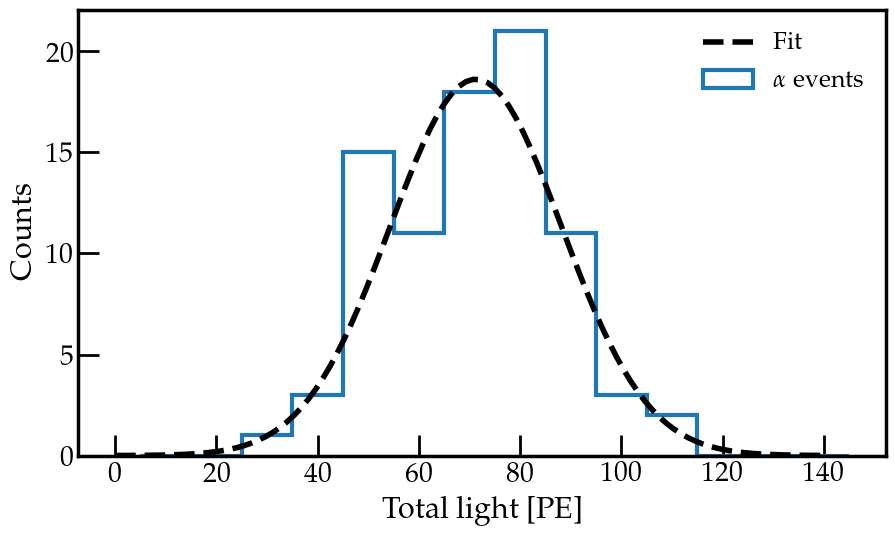

Day 2 runs: [31, 32, 33, 34, 35, 36, 37, 38]
Day 2 — fprompt median: 0.787


/Users/vikas-pc/Library/Python/3.8/lib/python/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Day 2 | t = 1675163514 | peak = 67.7 +/- 0.7 PE


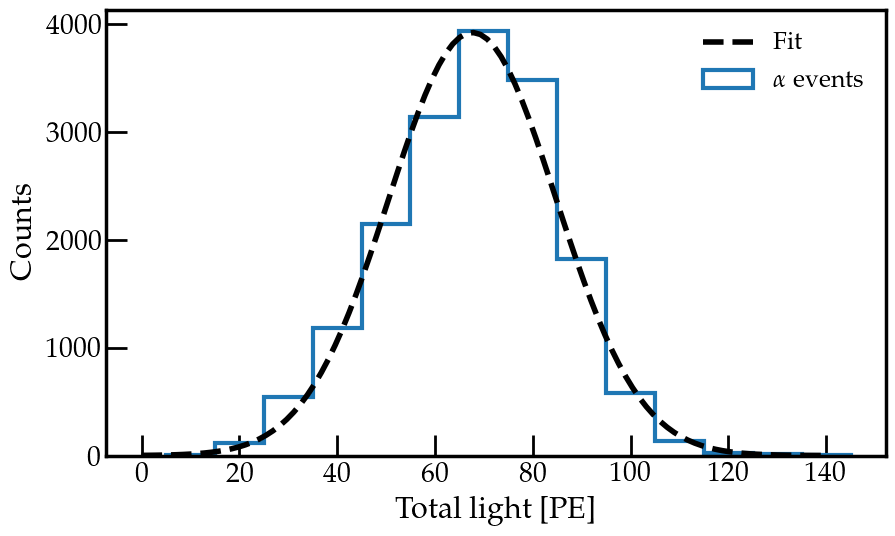

Day 3 runs: [39, 40, 41, 42, 43, 46]
Day 3 — fprompt median: 0.779


/Users/vikas-pc/Library/Python/3.8/lib/python/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Day 3 | t = 1675249914 | peak = 67.2 +/- 0.8 PE


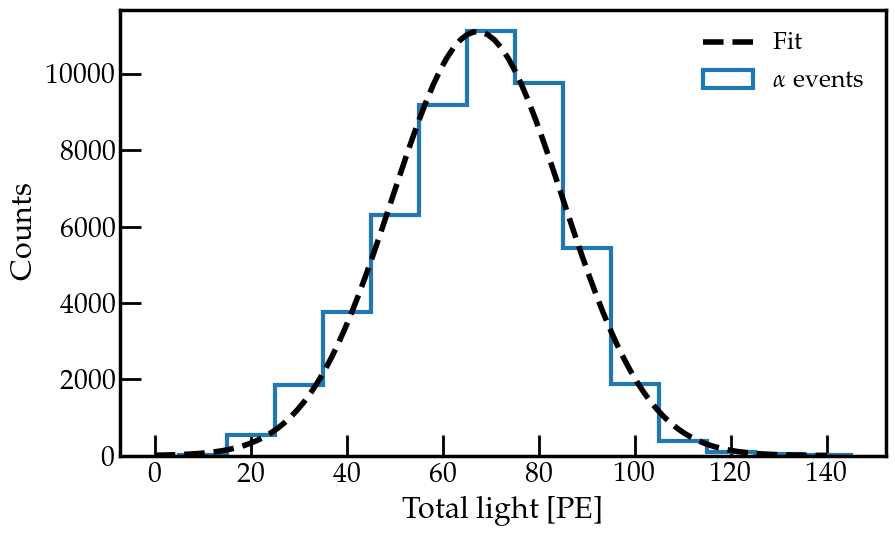

Day 4 runs: [48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62]
Day 4 — fprompt median: 0.761


/Users/vikas-pc/Library/Python/3.8/lib/python/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Day 4 | t = 1675336314 | peak = 76.3 +/- 0.6 PE


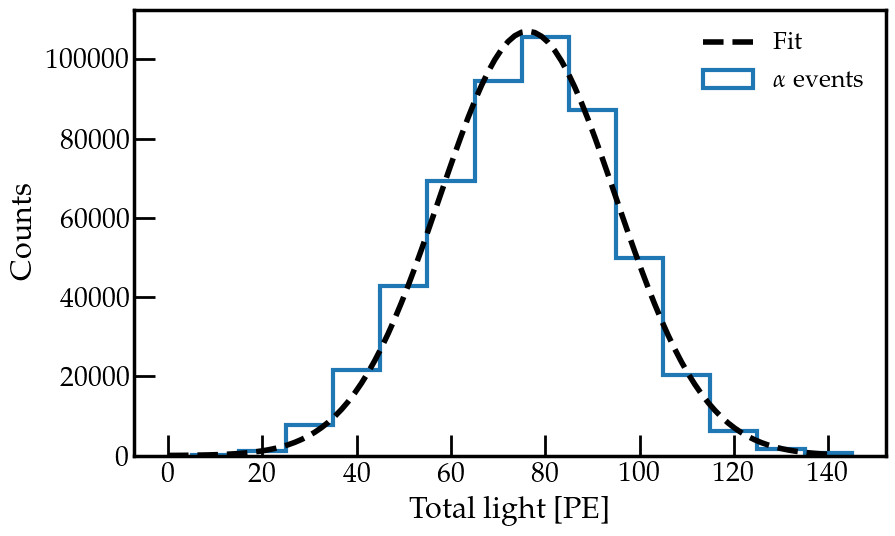

Day 5 runs: [63, 64, 65, 66, 67, 68]
Day 5 — fprompt median: 0.724


/Users/vikas-pc/Library/Python/3.8/lib/python/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Day 5 | t = 1675422714 | peak = 80.0 +/- 0.8 PE


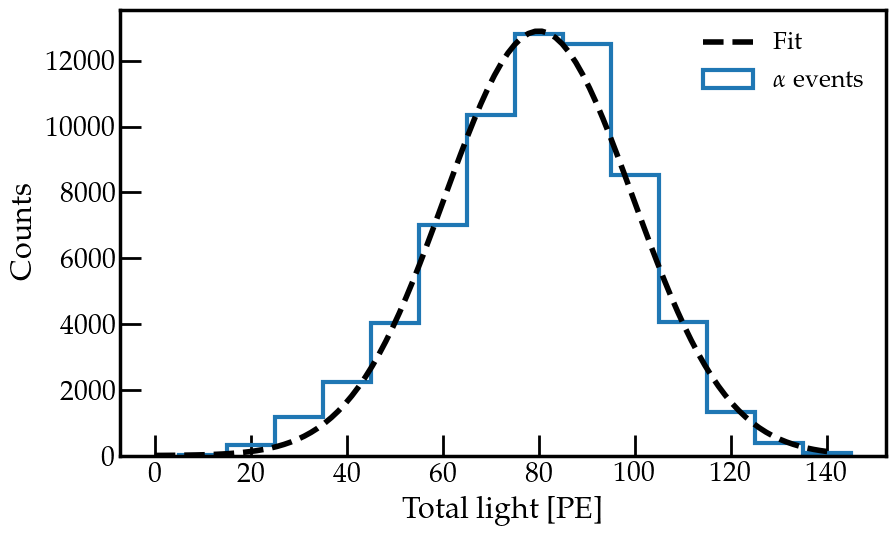

Day 6 runs: [71, 70, 72, 73]
Day 6 — fprompt median: 0.779


/Users/vikas-pc/Library/Python/3.8/lib/python/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Day 6 | t = 1675509114 | peak = 66.9 +/- 0.8 PE


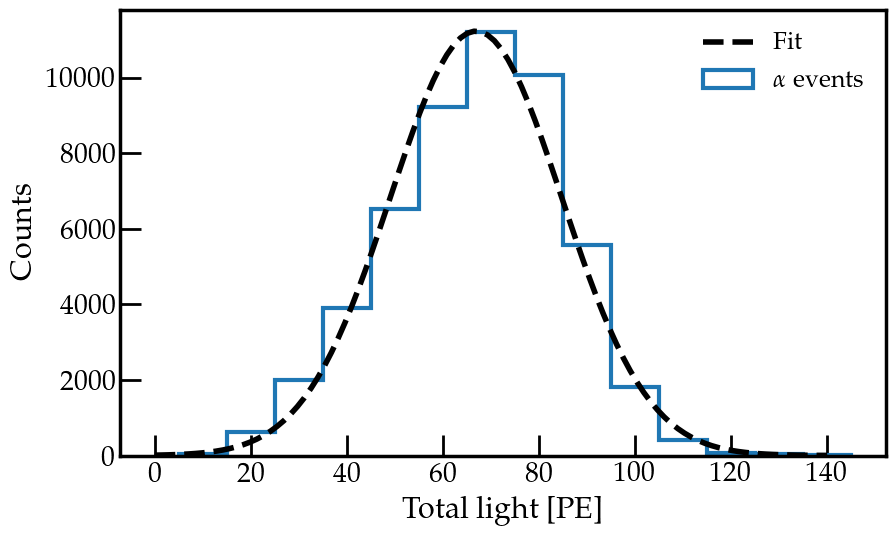

Day 7 runs: [74, 75]
Day 7 — fprompt median: 0.780


/Users/vikas-pc/Library/Python/3.8/lib/python/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Day 7 | t = 1675595514 | peak = 65.7 +/- 0.7 PE


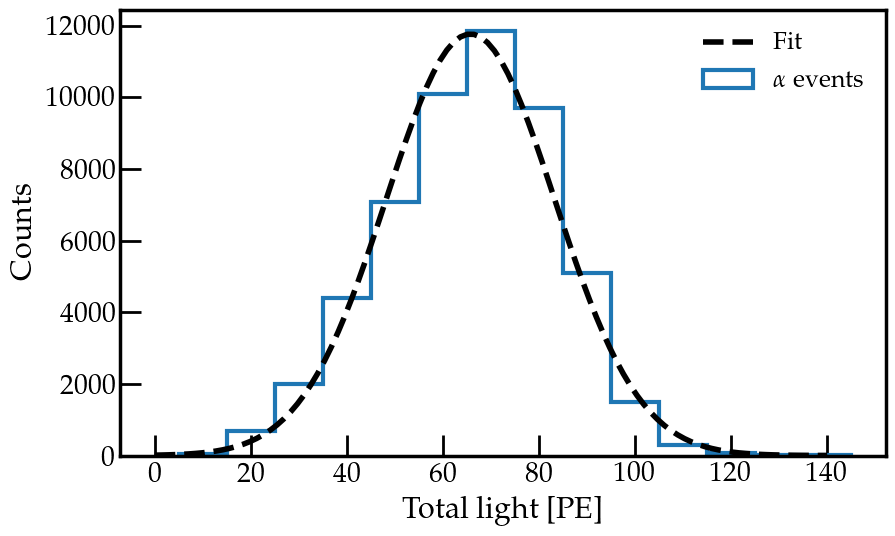

Day 8 runs: [79, 80, 81, 82, 83]
Day 8 — fprompt median: 0.779


/Users/vikas-pc/Library/Python/3.8/lib/python/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Day 8 | t = 1675681914 | peak = 67.0 +/- 0.8 PE


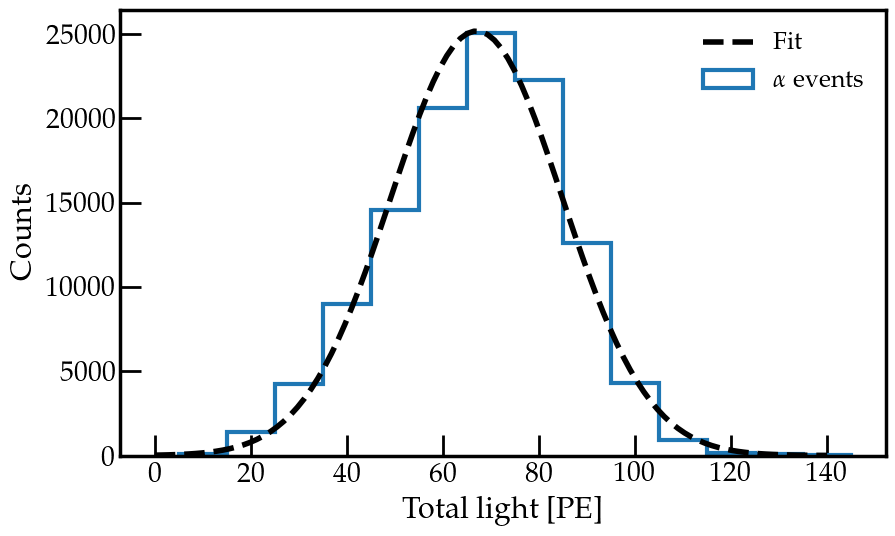

Day 9 runs: []
Day 9 — fprompt median: nan
Day 9 failed: Improper input: func input vector length N=3 must not exceed func output vector length M=0


/Users/vikas-pc/Library/Python/3.8/lib/python/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


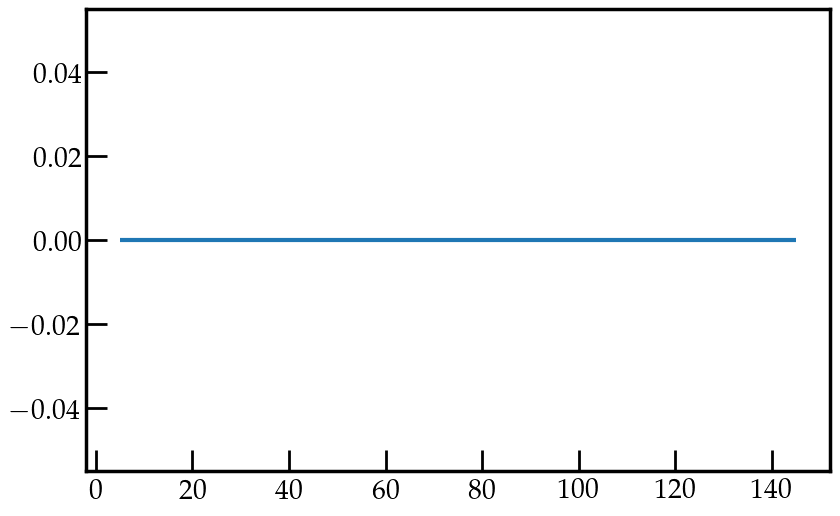

In [13]:
# spe_run: dict keyed by run number, values are (spe_value, spe_err, timestamp)
# Computed in the SPE calibration notebook and persisted to IPython's store
%store -r spe_run

# alpha_pos stores the Gaussian fit result for each day's alpha spectrum:
#   { unix_timestamp : [peak_PE, peak_err_PE] }
alpha_pos = {}

for day in range(1, 10):
    try:
        day_data = read_in_day_data(spe_run, filelist, day, daq_dir)
        results  = fit_day_results(day_data)

        timestamp = day_data[5]
        peak      = unp.nominal_values(results[0]['cen'])
        peak_err  = unp.std_devs(results[0]['cen'])

        alpha_pos[timestamp] = [peak, peak_err]
        print(f'Day {day} | t = {timestamp:.0f} | peak = {peak:.1f} +/- {peak_err:.1f} PE')
        plt.savefig(f'alpha_spectrum_day{day}.pdf')
        plt.show()

    except Exception as e:
        print(f'Day {day} failed: {e}')

## 8. DAQ Muon Analysis

Cosmic muons crossing the detector provide another light yield measurement. Because muons traverse the full active volume, their scintillation light reaches the PMT from all the PEN foil regions inside the detector. Tracking both simultaneously allows multiple cross-check of the PEN performance.

The muon signal is not extracted from the standard DAQ ROOT files. Instead, the DAQ processing saves a pre-computed late-light charge histogram per subrun to a text file (`muon_hist_subruns.txt`), which is loaded here. This was necessary because the muon events require a different integration window and pile-up treatment than the alpha events due to much higher energy deposition which can cause nonlinearlity in the PMT around the prompt window, handled outside the main processing chain.

Two quantities are extracted per day:

- **Muon peak position** (`muon_pos`): the Gaussian fit centre of the muon charge spectrum, in PE. Converted to PE/MeV using a factor of 116.83 — derived from simulations of the muon energy deposition (~300 MeV) in the active volume, after accounting for quenching corrections and the fact that we only look at late light in this data.
- **Triplet lifetime** (`lt_daq`): the exponential decay constant of the muon late-light pulse shape, extracted by `pulse_shape_day`. This is the primary argon purity monitor used to correct the alpha light yield in Block 9.

Day 1 runs: [26, 27, 28, 29, 30]
Day 1 | peak = 18489.6 +/- 32.2 PE
Day 2 runs: [31, 32, 33, 34, 35, 36, 37, 38]
Day 2 | peak = 18204.0 +/- 23.0 PE
Day 3 runs: [39, 40, 41, 42, 43, 44, 45, 46, 47]
Day 3 | peak = 4224.8 +/- 0.0 PE
Day 4 runs: [48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62]
Day 4 | peak = 19534.6 +/- 23.5 PE
Day 5 runs: [63, 64, 65, 66, 67, 68]
Day 5 | peak = 21148.9 +/- 307.7 PE
Day 6 runs: [71, 70, 72, 73]
Day 6 | peak = 18592.3 +/- 45.5 PE
Day 7 runs: [74, 75]
Day 7 | peak = 88242.4 +/- 0.0 PE
Day 8 runs: [79, 80, 81, 82, 83]
Day 8 | peak = 18166.7 +/- 35.8 PE
Day 9 runs: []
Day 9 failed: `ydata` must not be empty!


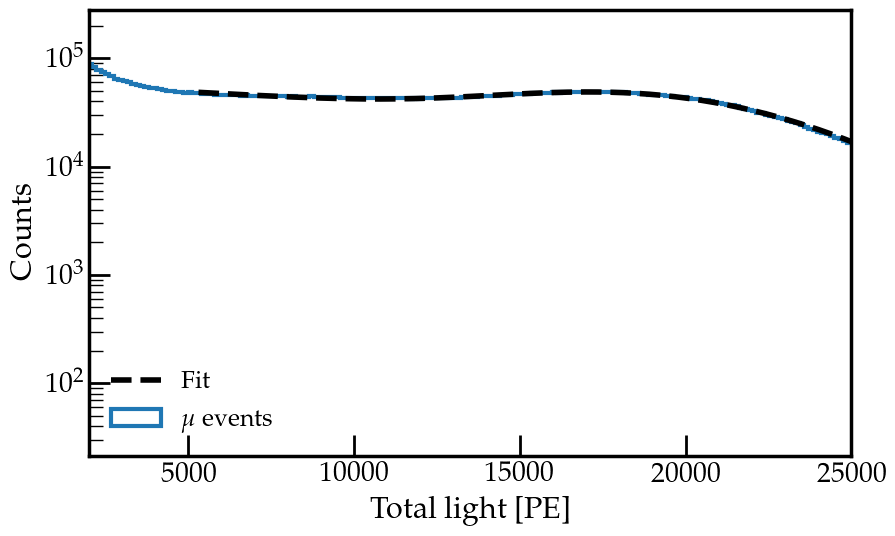

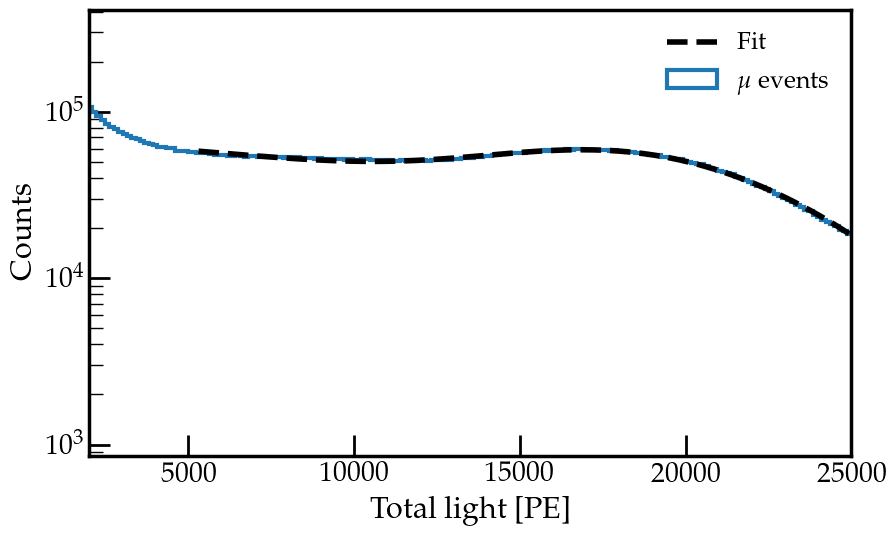

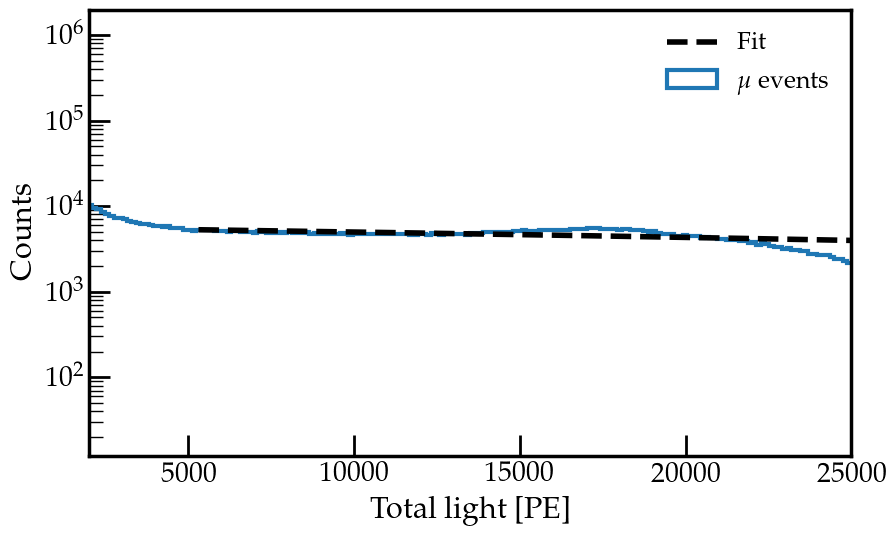

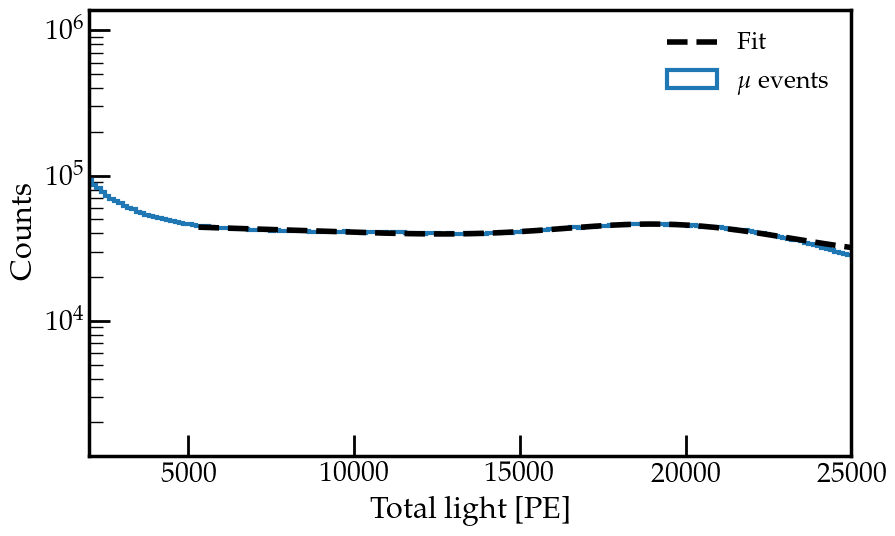

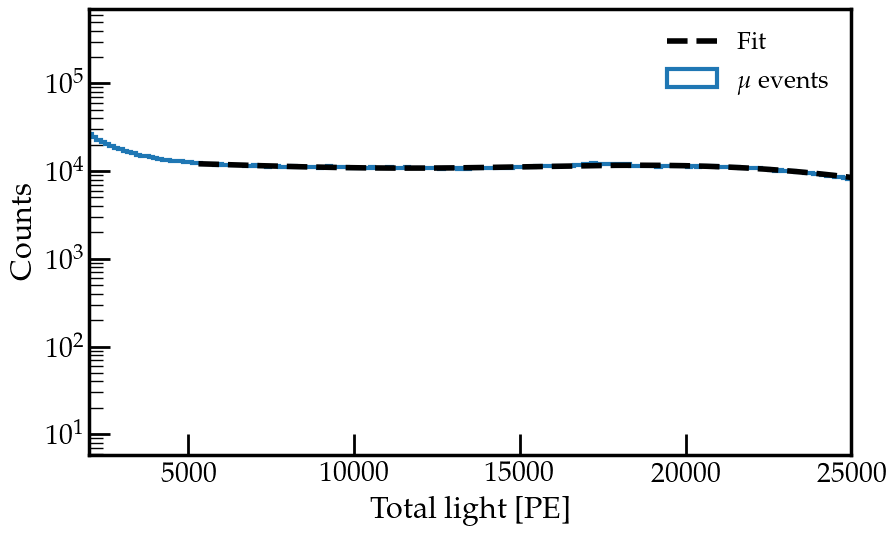

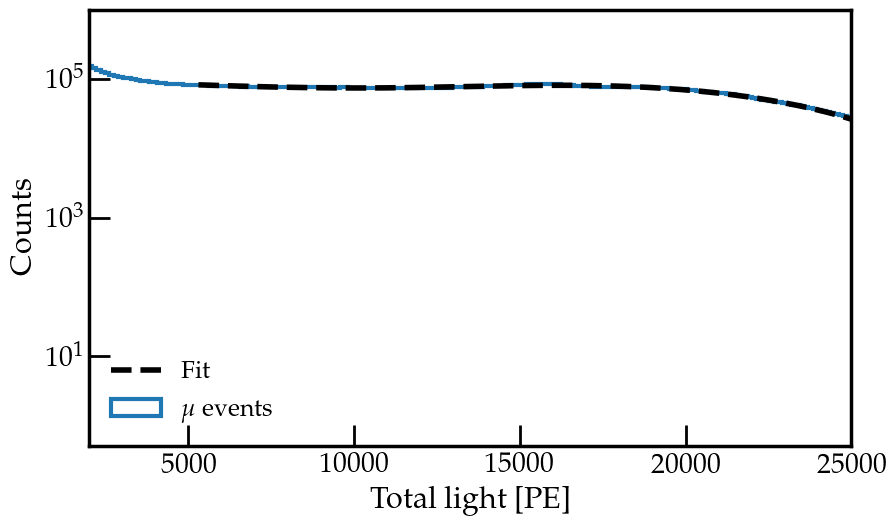

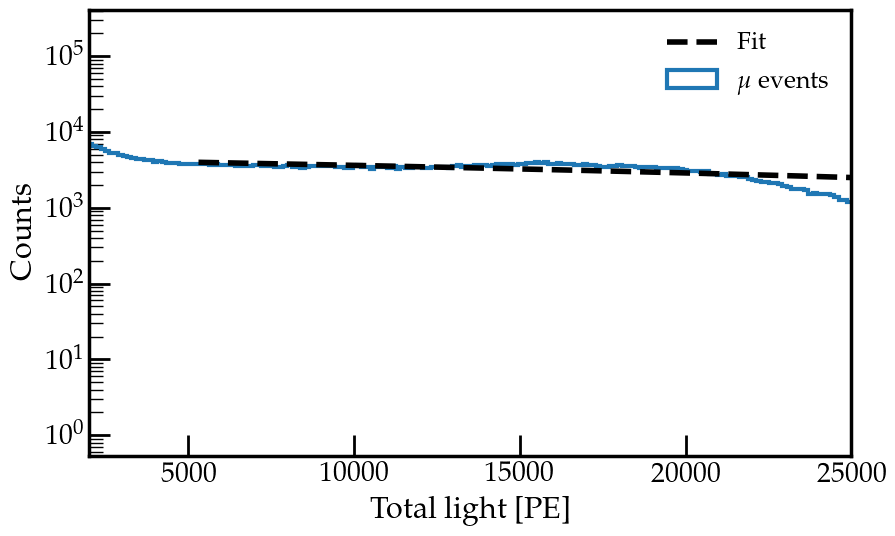

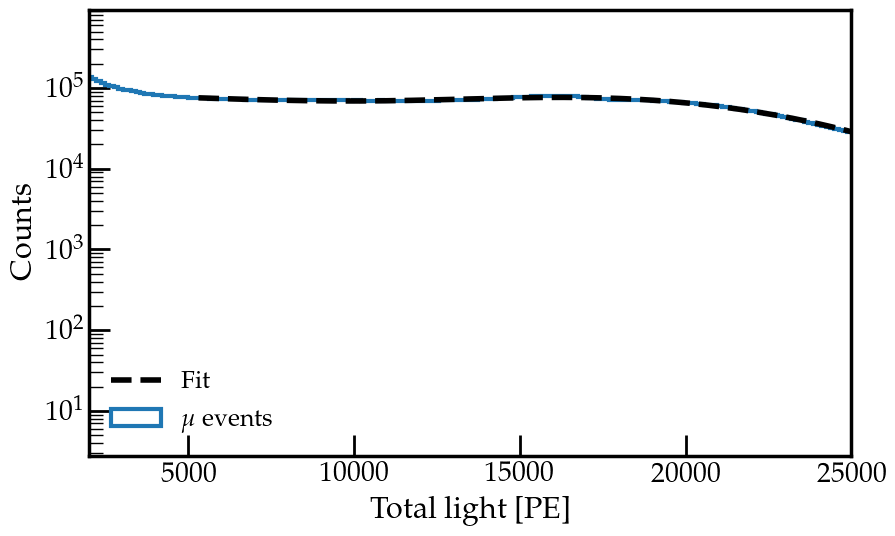

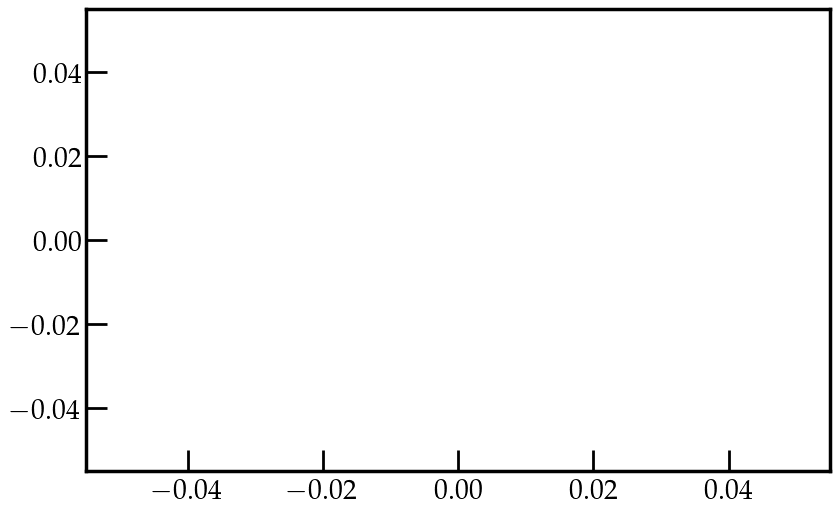

Day 1 runs: [26, 27, 28, 29, 30]
Baseline: 35.14 ± 1.25
Triplet lifetime: 1.409 ± 0.004 µs


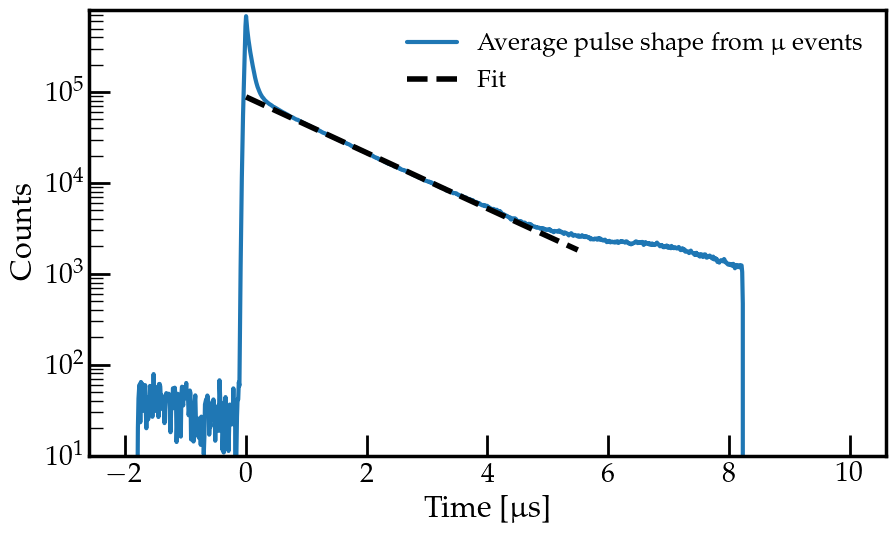

Day 1 | lt = 1.409 +/- 0.004 µs
Day 2 runs: [31, 32, 33, 34, 35, 36, 37, 38]
Baseline: 13.28 ± 0.62
Triplet lifetime: 1.403 ± 0.008 µs


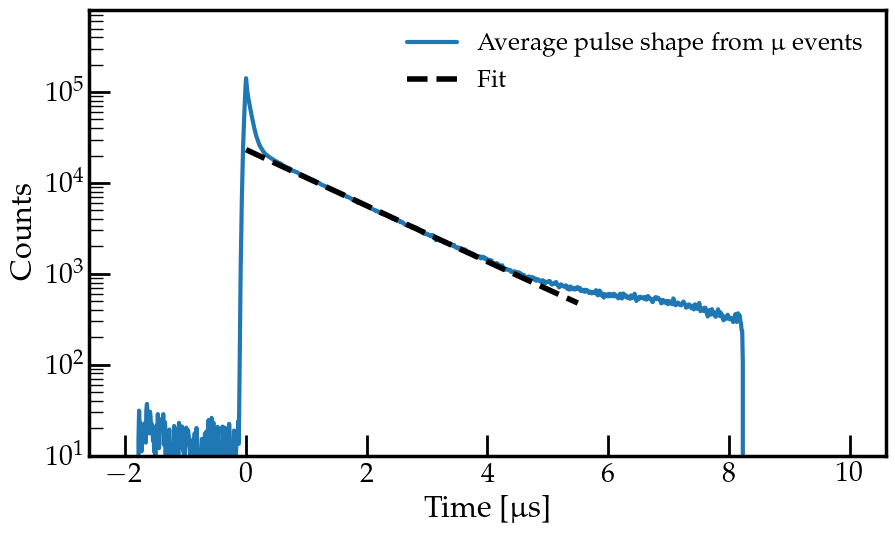

Day 2 | lt = 1.403 +/- 0.008 µs
Day 3 runs: [39, 40, 41, 42, 43, 44, 45, 46, 47]
Baseline: 131.27 ± 1.44
Triplet lifetime: 1.387 ± 0.003 µs


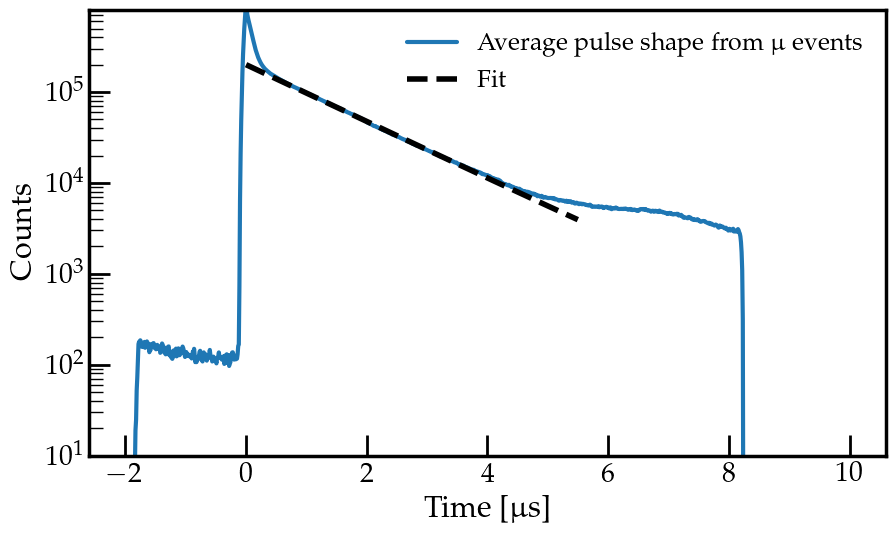

Day 3 | lt = 1.387 +/- 0.003 µs
Day 4 runs: [48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62]
Baseline: 76.07 ± 0.86
Triplet lifetime: 1.399 ± 0.007 µs


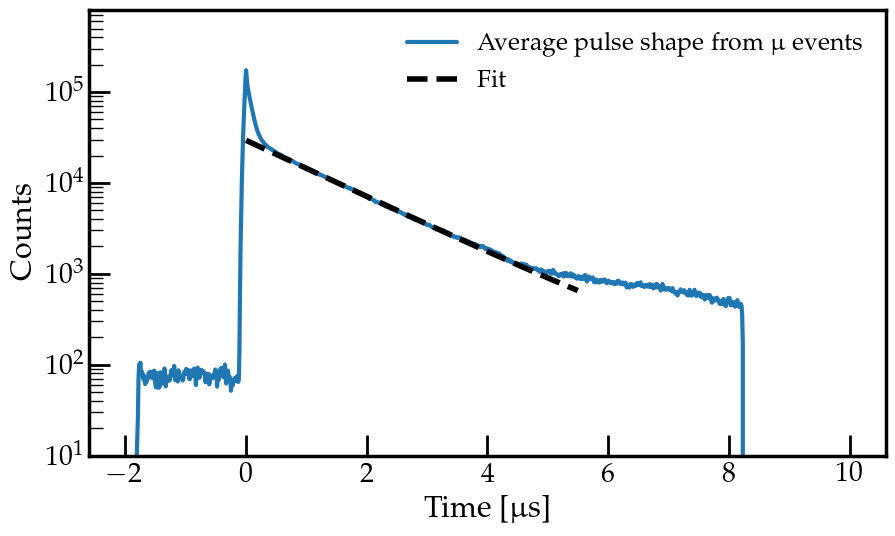

Day 4 | lt = 1.399 +/- 0.007 µs
Day 5 runs: [63, 64, 65, 66, 67, 68]
Baseline: 0.00 ± 0.00
Day 5 failed: Each lower bound must be strictly less than each upper bound.
Day 6 runs: [71, 70, 72, 73]
Baseline: 449.77 ± 3.26
Triplet lifetime: 1.388 ± 0.002 µs


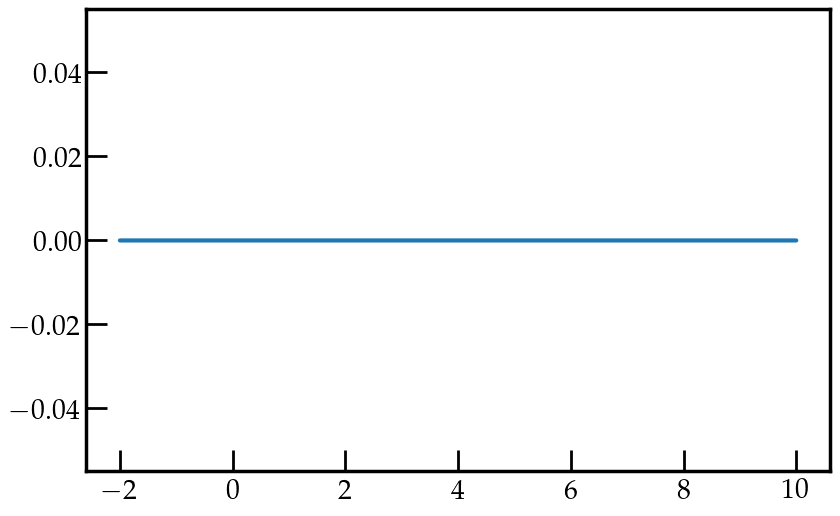

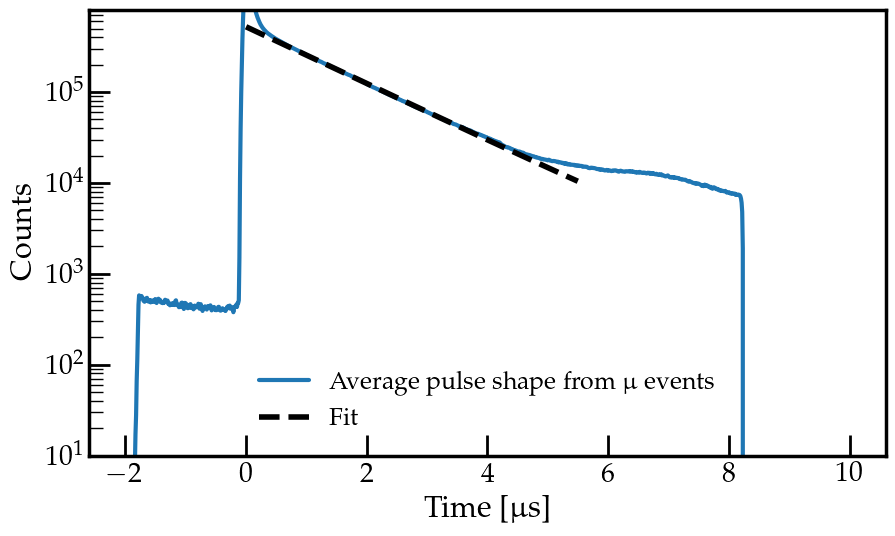

Day 6 | lt = 1.388 +/- 0.002 µs
Day 7 runs: [74, 75, 76, 77, 78]
Baseline: 517.60 ± 3.84
Triplet lifetime: 1.384 ± 0.001 µs


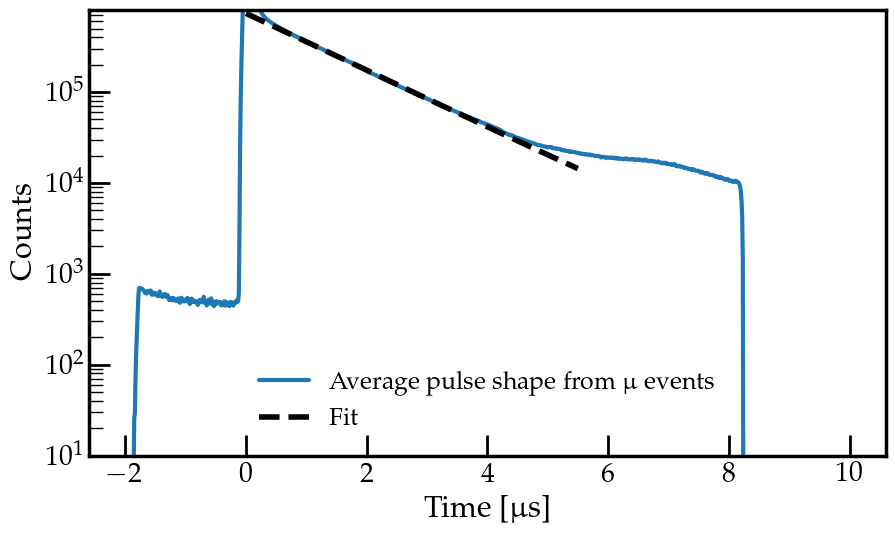

Day 7 | lt = 1.384 +/- 0.001 µs
Day 8 runs: [79, 80, 81, 82, 83]
Baseline: 360.75 ± 2.51
Triplet lifetime: 1.391 ± 0.002 µs


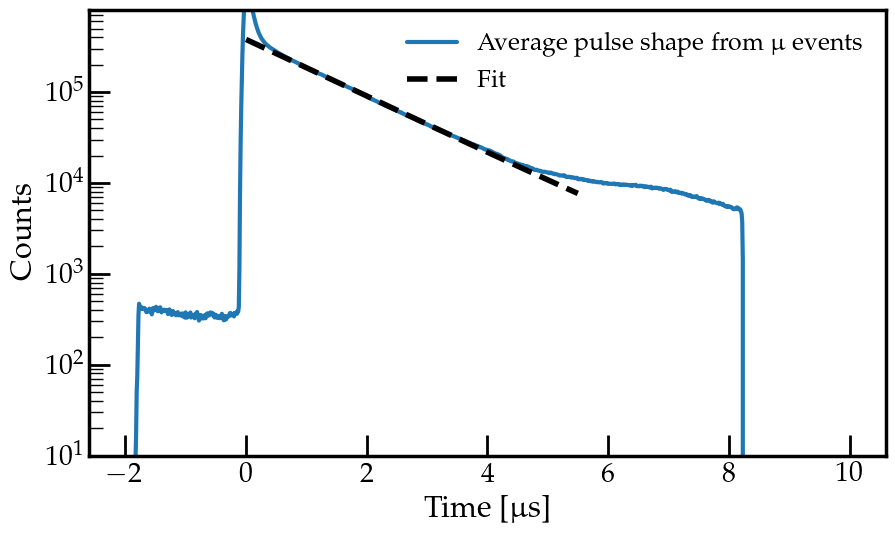

Day 8 | lt = 1.391 +/- 0.002 µs
Day 9 runs: [84, 85, 86, 87]
Baseline: 215.20 ± 2.78
Triplet lifetime: 1.385 ± 0.002 µs


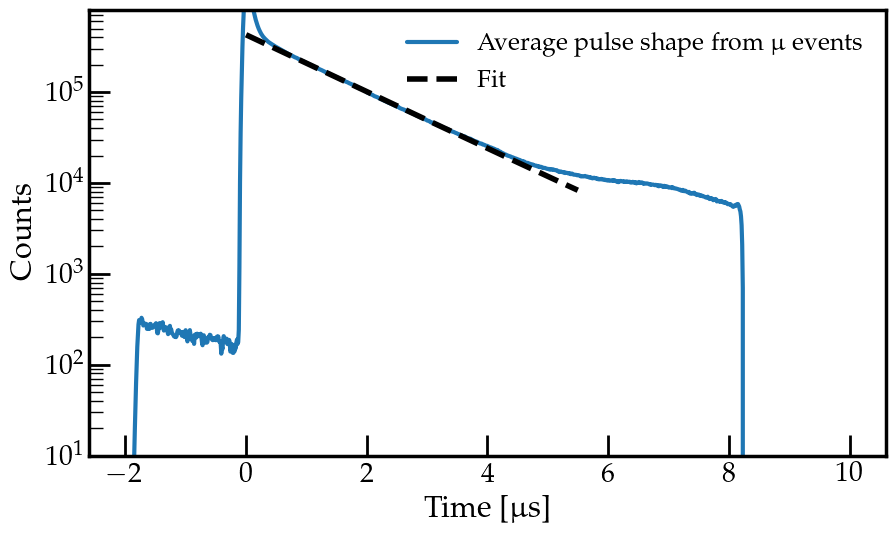

Day 9 | lt = 1.385 +/- 0.002 µs


<Figure size 960x600 with 0 Axes>

In [19]:
# Muon charge histograms are pre-computed by the DAQ processing chain
# and saved to a text file keyed by subrun timestamp
muon_hist_path = "/Users/vikas-pc/Desktop/dwarf_data/muon_hist_subruns.txt"

hist = {}
bin_data, val_data = [], []
with open(muon_hist_path, 'r') as histfile:
    for line in histfile:
        parts = line.split()
        if len(parts) == 2 and float(parts[1]) > 1600000000:
            if len(bin_data) > 0:
                hist[subrun_time] = [bin_data, val_data, last_key]
                bin_data, val_data = [], []
            last_key    = int(parts[0])
            subrun_time = float(parts[1])
        if len(parts) == 2 and not float(parts[1]) > 1600000000:
            if float(parts[0]) < 20000:
                bin_data.append(float(parts[0]))
                val_data.append(float(parts[1]))
    hist[subrun_time] = [bin_data, val_data, last_key]  # store final subrun

# --- Muon charge spectrum: peak position per day ---
%store -r spe_run
muon_pos, muon_pos_err, muon_time = [], [], []
t0 = 1674038700  # reference timestamp for day numbering

for day in range(1, 10):
    try:
        centre, err, timer = analyse_muons_day_data(spe_run, day, hist)
        if err < 1000:  # reject days where the fit did not converge
            muon_pos.append(centre)
            muon_pos_err.append(err)
            muon_time.append((timer - t0) / (24 * 3600))
            print(f'Day {day} | peak = {centre:.1f} +/- {err:.1f} PE')
    except Exception as e:
        print(f'Day {day} failed: {e}')

plt.savefig('muon_spectrum.pdf')
plt.show()

# --- Muon triplet lifetime from DAQ pulse shape ---
lt_daq = {}

for day in range(1, 10):
    try:
        time_day, lt, lt_err = pulse_shape_day(spe_run, day)
        lt_daq[time_day] = [lt, lt_err]
        print(f'Day {day} | lt = {lt:.3f} +/- {lt_err:.3f} µs')
    except Exception as e:
        print(f'Day {day} failed: {e}')

plt.savefig('pulse_shape.pdf')
plt.show()

## 9. Oscilloscope Muon Analysis

For the first ~4 days of the run, the main DAQ was not yet operational, so a oscilloscope was used to record PMT waveforms triggered on cosmic muons. This is the only source of data for this period.

`osc_analysis` groups oscilloscope runs by day, accumulates the late-light histogram across all runs in that day, and extracts two quantities:

- **Triplet lifetime** (`osc_lt`): from the exponential decay fit to the accumulated histogram — provides the purity monitor for the early run period
- **Muon peak position** (`osc_pos`): from the Gaussian fit to the muon charge spectrum, normalised by 116.83 to convert to PE/MeV after accounting for the simulated muon energy deposition, quenching corrections, and the alpha-to-muon ionisation density difference

Day 1 oscilloscope runs: [12, 13, 14, 15, 16, 17]
Baseline: -328.31 ± 10.40
Triplet lifetime: 1.393 ± 0.010 µs


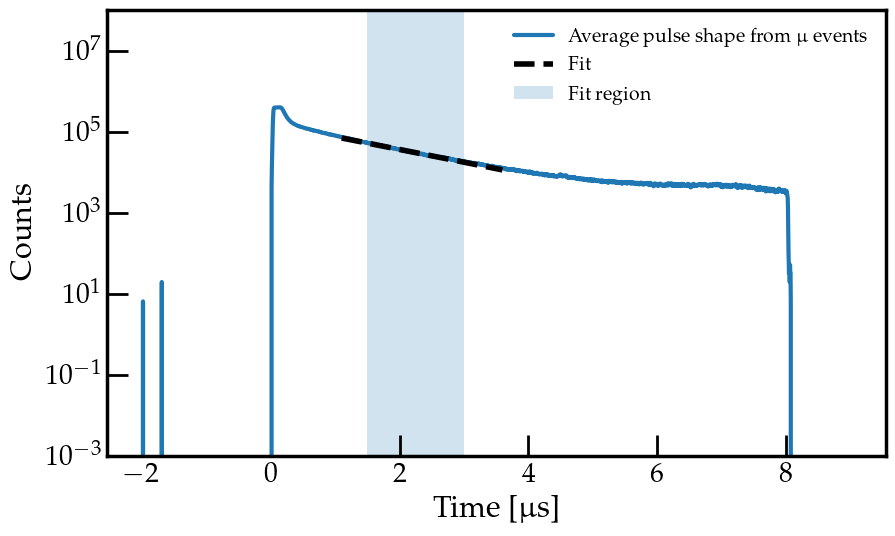

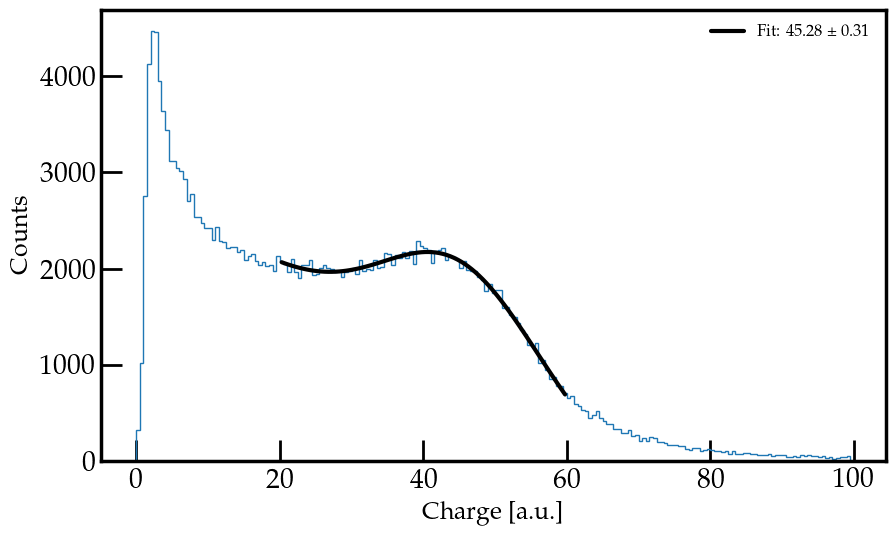

Day 1 | lt = 1.393 +/- 0.010 µs | peak = 45.28 +/- 0.31
Day 2 oscilloscope runs: [18, 19, 20]
Baseline: -453.74 ± 13.07
Triplet lifetime: 1.398 ± 0.008 µs


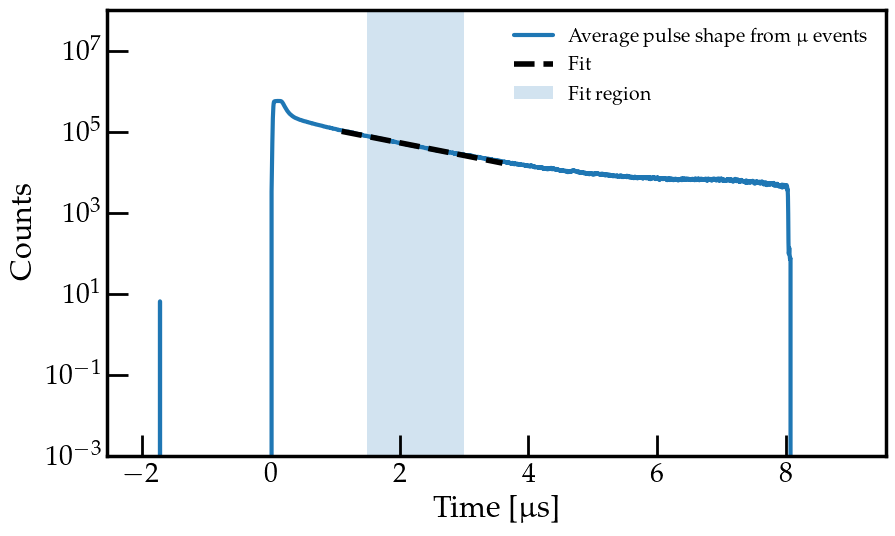

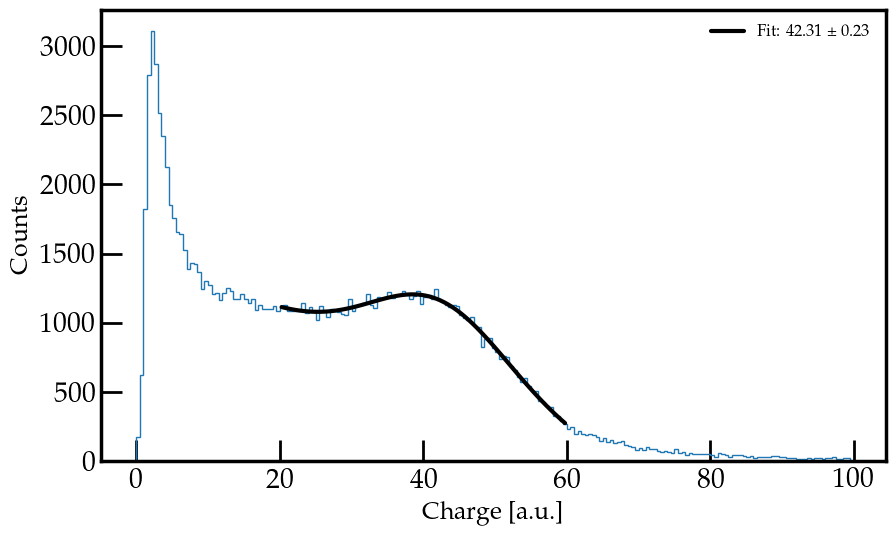

Day 2 | lt = 1.398 +/- 0.008 µs | peak = 42.31 +/- 0.23
Day 3 oscilloscope runs: [21, 22, 23]
Baseline: -433.93 ± 9.85
Triplet lifetime: 1.405 ± 0.007 µs


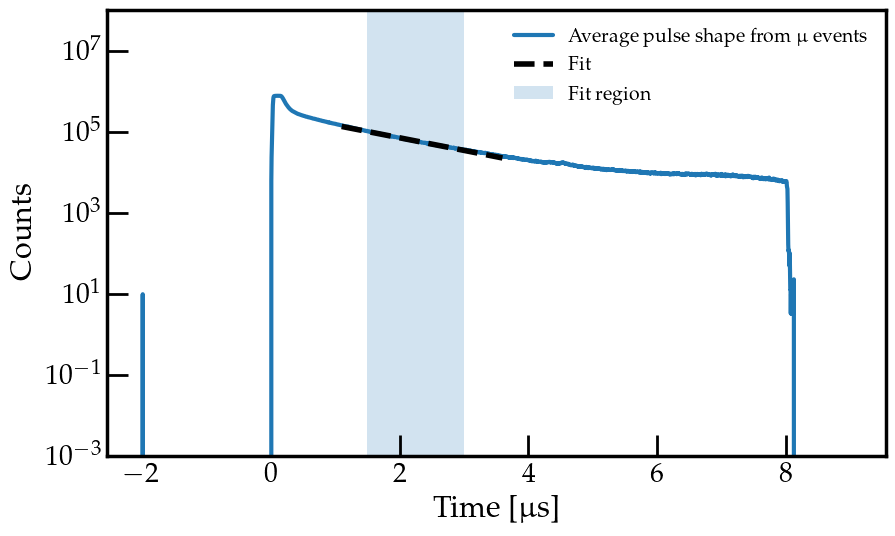

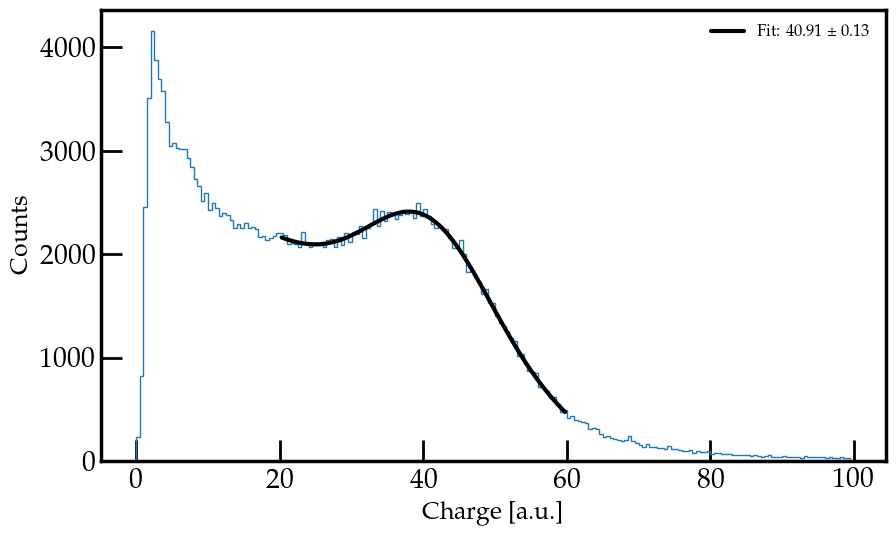

Day 3 | lt = 1.405 +/- 0.007 µs | peak = 40.91 +/- 0.13
Day 4 oscilloscope runs: [24, 25]
Baseline: -286.36 ± 8.85
Triplet lifetime: 1.385 ± 0.008 µs


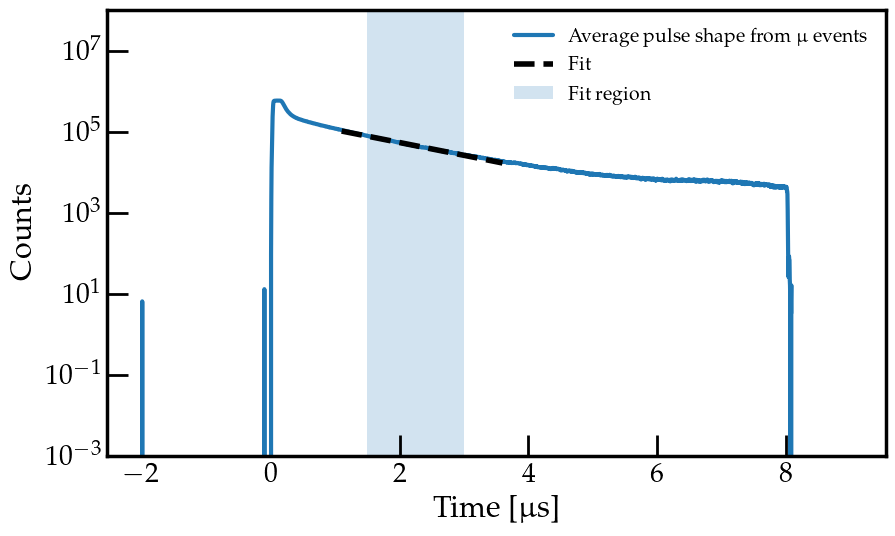

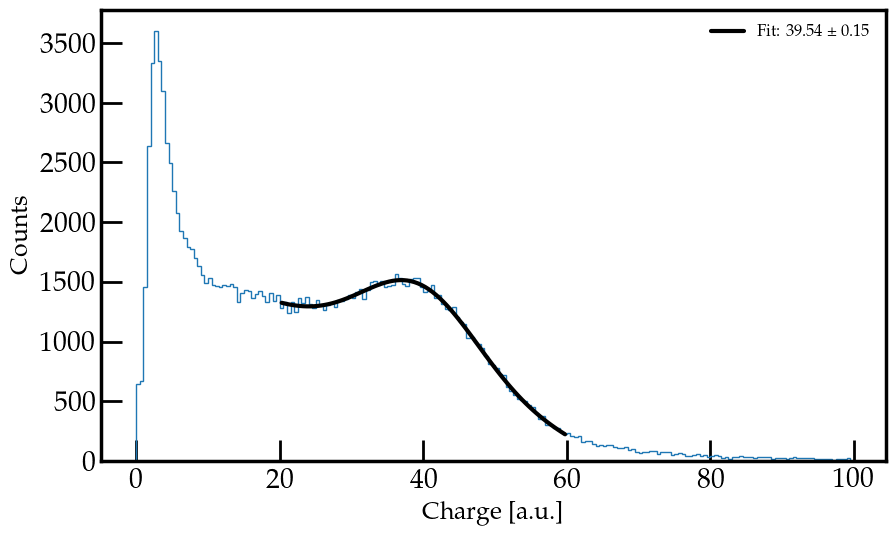

Day 4 | lt = 1.385 +/- 0.008 µs | peak = 39.54 +/- 0.15


In [21]:
# osc_data restored from store — saved as processed_osc_data in Block 6
%store -r processed_osc_data
osc_data = processed_osc_data

# osc_time defined here again for self-contained execution
osc_time = {
    12: 1674745680, 13: 1674769860, 14: 1674769860 + 3600,
    15: 1674818640, 16: 1674822000, 17: 1674823980,
    18: 1674832620, 19: 1674834420, 20: 1674843780,
    21: 1674919260, 22: 1674951060, 23: 1675003080,
    24: 1675033080, 25: 1675070580,
}

osc_lt  = {}
osc_pos = {}

for day in range(1, 5):
    try:
        lt, lt_err, daytime, feature, feature_err = osc_analysis(osc_data, day, osc_time)
        osc_lt[daytime]  = [lt, lt_err]
        osc_pos[daytime] = [feature / 116.83, feature_err / 116.83]
        print(f'Day {day} | lt = {lt:.3f} +/- {lt_err:.3f} µs | peak = {feature:.2f} +/- {feature_err:.2f}')
    except Exception as e:
        print(f'Day {day} failed: {e}')

## 10. Triplet Lifetime Correction and Light Yield Evolution

The raw alpha and muon light yields measured in Blocks 7–9 are affected by argon purity: as electronegative contaminants accumulate, they quench the slow triplet component of the scintillation signal, reducing the total measured charge. To compare light yields across days, each measurement must be corrected back to what it would have been at the purity of the first good day (taken as the reference).

The correction uses the triplet lifetime measured simultaneously with the light yield. For a purely exponential late-light component, the suppression factor is simply `lt_max / lt`, where `lt_max` is the lifetime at maximum purity. Alphas and muons require slightly different corrections because they have different prompt/late light fractions — alphas have ~22% prompt light which is unaffected by purity, so only the 78% late-light component is corrected. For muons, only late light is integrated, so the full correction is applied.

The alpha light yield is converted from PE to PE/MeV using `factor = E × f_holder × f_quench × f_geom = 4.8 × 0.38 × 0.72 × 0.9393`, where 4.8 MeV is the alpha energy, 0.38 is the fraction of photons escaping the source holder, 0.72 is the correction for quenching in nuclear recoils, and 0.9393 is a geometric acceptance factor.

The muon light yield is converted using a factor derived from the simulated energy deposition and SPE calibration. The oscilloscope muon points have no independent SPE calibration — they are normalised to the first DAQ muon point, with an additional systematic error growing linearly with the time separation from that anchor point.

The two-panel figure shows:
- **Top**: purity-corrected light yield in PE/MeV vs day for alphas (black), DAQ muons (blue crosses), and oscilloscope muons (light blue). Argon refill times are marked in red.
- **Bottom**: triplet lifetime vs day — the direct argon purity monitor.

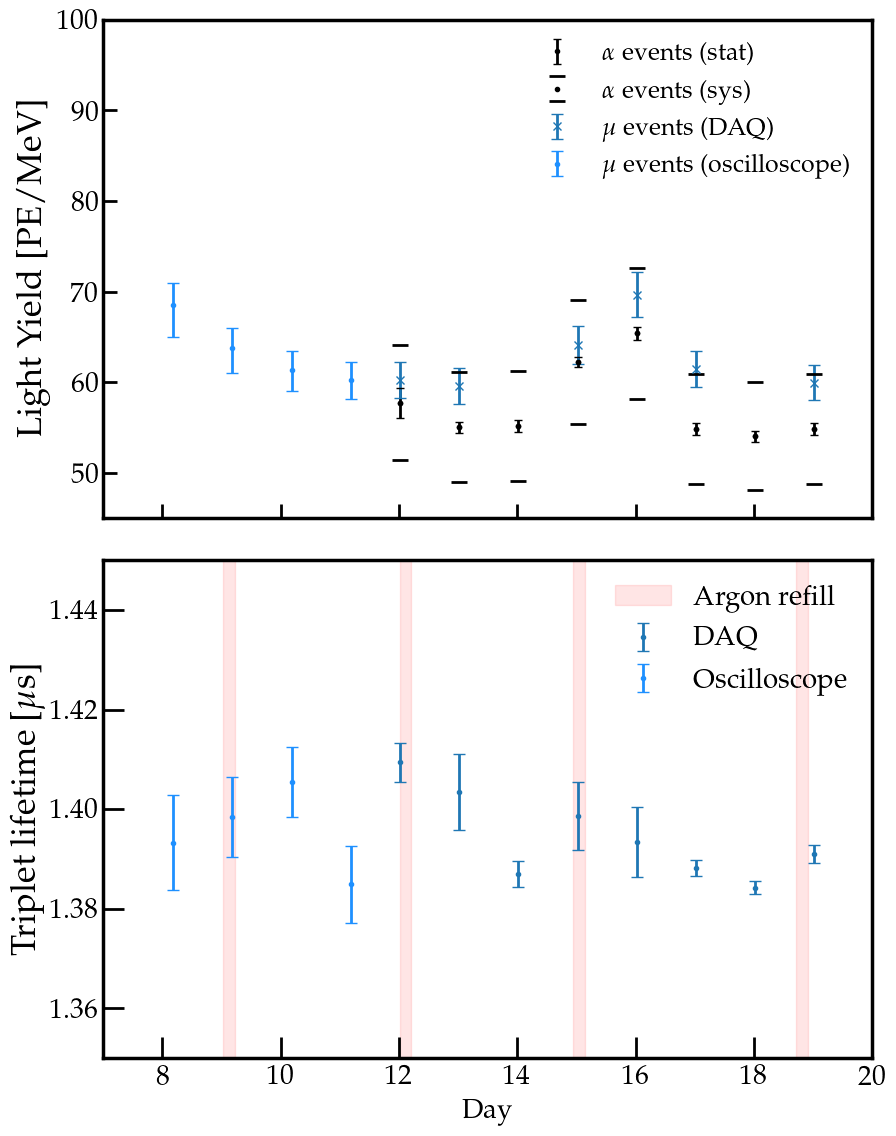

In [42]:
def muon_triplet_corr(energy, energy_err, lt, lt_err, max_lt, max_lt_err):
    """
    Correct muon light yield for argon purity using the triplet lifetime.
    Muons are treated as 100% late light within the integration window,
    so the full charge scales as max_lt / lt.
    """
    corr_energy = energy * max_lt / lt
    corr_err    = corr_energy * np.sqrt((energy_err / energy)**2 +
                                        (lt_err / lt)**2 +
                                        (max_lt_err / max_lt)**2)
    return corr_energy, corr_err


def alpha_triplet_corr(energy, energy_err, lt, lt_err, max_lt, max_lt_err):
    """
    Correct alpha light yield for argon purity using the triplet lifetime.
    Alphas have ~22% prompt light (unaffected by purity) and ~78% late light.
    Only the late-light component is scaled by max_lt / lt.
    """
    corr_energy = energy * 0.78 * max_lt / lt + energy * 0.22
    err_late    = energy * 0.78 * max_lt / lt * np.sqrt((energy_err / energy)**2 +
                                                         (lt_err / lt)**2 +
                                                         (max_lt_err / max_lt)**2)
    err_prompt  = 0.22 * energy_err
    corr_err    = np.sqrt(err_late**2 + err_prompt**2 +
                          2 * (0.78 * max_lt / lt) * 0.22 * energy_err**2)
    return corr_energy, corr_err


t0     = 1674038700   # reference timestamp for day axis
# alpha energy [MeV] * quenching * ionisation yield * geometric acceptance
factor_alpha = 4.8 * 0.38 * 0.72 * 0.9393

# Interpolate missing lt_daq entry by averaging the two neighbouring days
lt_daq[1675422714.0] = [
    (lt_daq[1675336314.0][0] + lt_daq[1675509114.0][0]) / 2,
    np.sqrt(lt_daq[1675336314.0][1]**2 + lt_daq[1675509114.0][1]**2)
]

# --- Alpha light yield ---
runtime  = [(key - t0) / (24 * 3600) for key in alpha_pos]
pos      = [alpha_pos[key][0] / factor_alpha for key in alpha_pos]
err      = [alpha_pos[key][1] / factor_alpha for key in alpha_pos]
lt       = [lt_daq[key][0] for key in alpha_pos]
lt_err   = [lt_daq[key][1] for key in alpha_pos]
lt_max, lt_max_err = lt[0], lt_err[0]   # first day as purity reference

corr_pos, corr_pos_err = [], []
for k in range(len(pos)):
    cp, ce = alpha_triplet_corr(pos[k], err[k], lt[k], lt_err[k], lt_max, lt_max_err)
    corr_pos.append(cp)
    corr_pos_err.append(ce)

# Systematic error from quenching (7%) and ionisation yield (2%) uncertainties
sys_err = [corr_pos[k] * np.sqrt((0.07 / 0.72)**2 + (0.02 / 0.38)**2)
           for k in range(len(runtime))]

# --- DAQ muon light yield ---
# factor for going to PE/MEV = simulated_energy_deposition 
factor_muon     = 306.9983263891399
factor_muon_err = 10

muon_corr, muon_corr_err = [], []
for k in range(len(muon_time)):
    e    = muon_pos[k] / factor_muon
    e_err = e * np.sqrt((muon_pos_err[k] / muon_pos[k])**2 +
                        (factor_muon_err / factor_muon)**2)
    cp, ce = muon_triplet_corr(e, e_err, lt[k], lt_err[k], lt_max, lt_max_err)
    muon_corr.append(cp)
    muon_corr_err.append(ce)

# --- Oscilloscope muon light yield ---
# No independent SPE calibration — normalise to first DAQ muon point
first_muon_daq      = muon_corr[0]
first_muon_daq_err  = muon_corr_err[0]
first_muon_daq_time = muon_time[0]

lt_osc     = [osc_lt[key][0] for key in osc_lt]
lt_osc_err = [osc_lt[key][1] for key in osc_lt]

osc_runtime = [(key - t0) / (24 * 3600) for key in osc_pos]
osc_pos_val = [osc_pos[key][0] for key in osc_pos]
osc_pos_err = [osc_pos[key][1] for key in osc_pos]

osc_corr, osc_corr_err = [], []
for k in range(len(osc_pos_val)):
    cp, ce = muon_triplet_corr(osc_pos_val[k], osc_pos_err[k],
                               lt_osc[k], lt_osc_err[k], lt_max, lt_max_err)
    osc_corr.append(cp)
    osc_corr_err.append(ce)

# Normalise oscilloscope points to first DAQ muon point
norm_factor     = first_muon_daq / osc_corr[-1]
osc_pos_norm    = [osc_corr[k] * norm_factor for k in range(len(osc_corr))]
osc_err_upper   = []
osc_err_lower   = []
for k in range(len(osc_pos_norm)):
    stat_err = osc_corr[k] * norm_factor * np.sqrt(
        (osc_corr_err[k] / osc_corr[k])**2 +
        (first_muon_daq_err / first_muon_daq)**2)
    # SPE drift uncertainty grows linearly with time from anchor point
    spe_err  = (first_muon_daq_time - osc_runtime[k]) * 0.01 * osc_pos_norm[k]
    osc_err_upper.append(stat_err)
    osc_err_lower.append(np.sqrt(stat_err**2 + spe_err**2))

asym_err = np.array(list(zip(osc_err_lower, osc_err_upper))).T

# --- Plot ---
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9.6, 12))

ax1.errorbar(runtime, corr_pos, yerr=corr_pos_err,
             capsize=3, fmt='.', color='k', elinewidth=2, lw=1,
             label=r'$\alpha$ events (stat)')
ax1.errorbar(runtime, corr_pos, yerr=sys_err,
             capsize=6, fmt='.', color='k', capthick=2, elinewidth=0, lw=1,
             label=r'$\alpha$ events (sys)')
ax1.errorbar([muon_time[k] for k in range(len(muon_time))], muon_corr,
             yerr=muon_corr_err,
             capsize=4, fmt='x', color='tab:blue', elinewidth=2, lw=1,
             label=r'$\mu$ events (DAQ)')
ax1.errorbar(osc_runtime, osc_pos_norm, yerr=asym_err,
             capsize=4, fmt='.', color='#1E90FF', elinewidth=2, lw=1,
             label=r'$\mu$ events (oscilloscope)')

ax1.set_ylabel('Light Yield [PE/MeV]', fontsize=25)
ax1.set_ylim(45, 100)
ax1.set_xlim(7, 20)
ax1.legend(fontsize=18, loc='upper right')
ax1.tick_params(length=10)

lt_runtime = [(key - t0) / (24 * 3600) for key in lt_daq if (key - t0) / (24 * 3600) < 20]
lt_vals    = [lt_daq[key][0] for key in lt_daq if (key - t0) / (24 * 3600) < 20]
lt_errs    = [lt_daq[key][1] for key in lt_daq if (key - t0) / (24 * 3600) < 20]
ax2.errorbar(lt_runtime, lt_vals, yerr=lt_errs,
             capsize=4, fmt='.', color='tab:blue', elinewidth=2, lw=1,
             label='DAQ')
ax2.errorbar([(key - t0) / (24 * 3600) for key in osc_lt],
             [osc_lt[key][0] for key in osc_lt],
             yerr=[osc_lt[key][1] for key in osc_lt],
             capsize=4, fmt='.', color='#1E90FF', elinewidth=2, lw=1,
             label='Oscilloscope')
ax2.set_ylabel(r'Triplet lifetime [$\mu$s]', fontsize=25)
ax2.set_ylim(1.35, 1.45)
ax2.set_xlabel('Day', fontsize=20)
ax2.legend(fontsize=20, loc='upper right')

# Mark argon refill times
color = 'red'
for fill_t in [1675093560, 1674835800, 1675347300, 1675672800]:
    fill_day = (fill_t - t0) / (24 * 3600)
    ax2.axvspan(fill_day - 0.2, fill_day, color=color, alpha=0.1)
ax2.axvspan(0, 0.1, color=color, alpha=0.1, label='Argon refill')
ax2.legend(fontsize=20, loc='upper right')

plt.tight_layout()
plt.savefig('ly_evolution.png')
plt.show()

## 11. Spatial Scan and MC Comparison

To constrain the PEN wavelength-shifting efficiency over large-area foils, the alpha source was moved to different positions and angles within the detector and the measured light yield compared to GEANT4 Monte Carlo predictions. The MC simulates the full photon transport — VUV emission, PEN absorption and re-emission, and PMT detection — for a given assumed PEN WLS efficiency (`PENWLSE`). Comparing data to MC at multiple source positions over-constrains the geometry and reduces systematic uncertainties.

Two scan types were performed:

- **Z-scan** (runs 85, 89, 86): source at bottom, middle, and top of the detector along the central axis, PMT viewing angle fixed at centre. Peak positions are taken from earlier processed runs and corrected for a small geometry shift between scan periods.
- **Angular scan** (runs 94–99): source at top/middle/bottom for three PMT viewing angles — centre, right, and left. SPE calibration was performed independently for these runs as they fall outside the main run period.

The angular scan is the primary result: because the PEN foil subtends different solid angles depending on the source position and viewing angle, the position-dependence of the light yield is a strong discriminator of PEN efficiency. Each data point is compared to the MC expectation band (shaded), where the band width reflects the 20% uncertainty on `PENWLSE`. The pre-computed results are restored from store rather than reprocessed, as the angle runs require a different DAQ software version to read.

The `factor = f_geom × E × f_holder × f_quench = 0.9393 × 4.8 × 0.38 × 0.72` converts alpha peak position from PE to PE/MeV, consistent with Block 10.

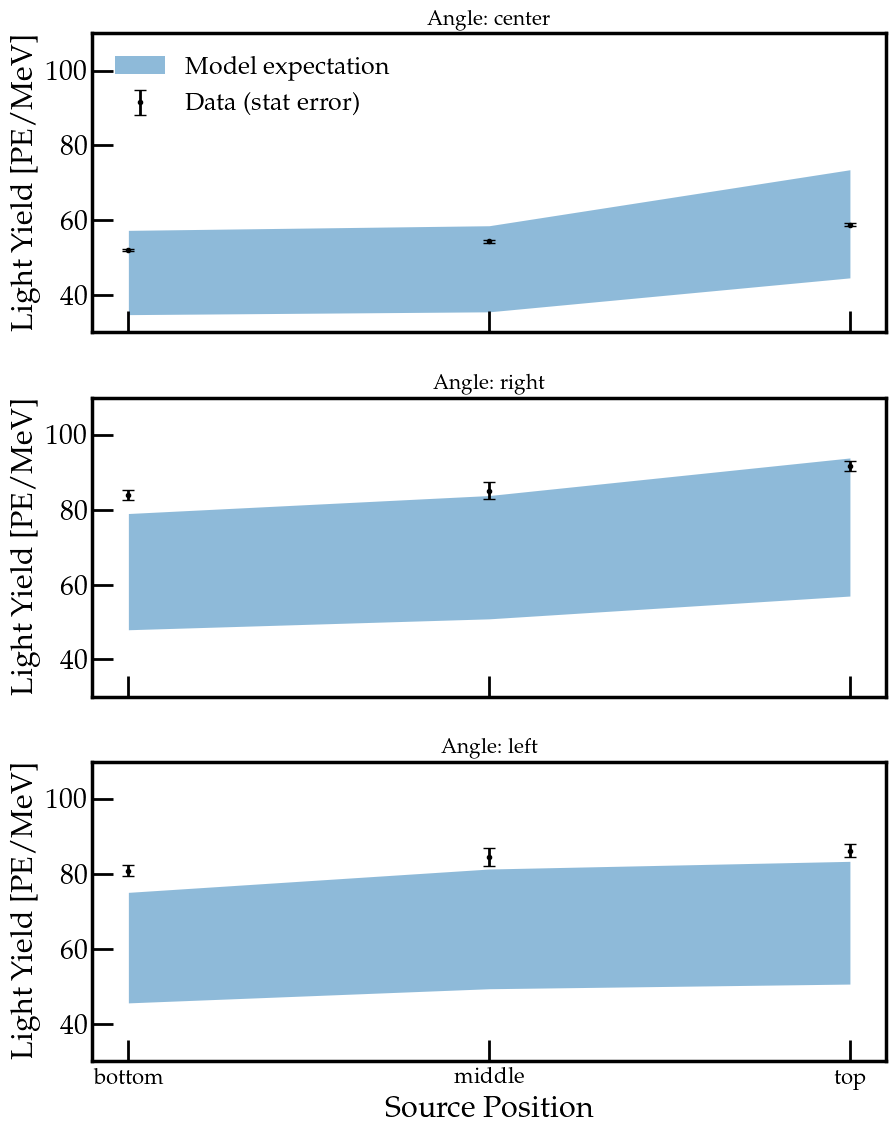

In [43]:
%store -r alpha_pos_angle

# --- MC expectation bands ---
# MC light yield: E * aQ * Y * eff_pmt * PENWLSE / (E * f_holder_mc * aQ)
# Note: MC uses f_holder = 0.394 (slightly different from data 0.38) to match paper value
E, aQ, Y, eff_pmt      = 4.8, 0.72, 40000, 0.17
PENWLSE, dPENWLSE       = 0.58, 0.20
delta_Y, delta_eff_pmt  = 0.10, 0.10

peak = E * aQ * Y * eff_pmt * PENWLSE / (4.8 * 0.394 * 0.72)
err  = np.sqrt(delta_Y**2 + delta_eff_pmt**2 + dPENWLSE**2) * peak

mc_mid   = [[peak * k, err * k] for k in [0.0058969,  0.00469526, 0.00459585]]
mc_right = [[peak * k, err * k] for k in [0.00753044, 0.00672407, 0.00633812]]
mc_left  = [[peak * k, err * k] for k in [0.00669272, 0.00652811, 0.00602723]]

# --- 3-panel plot: data vs MC for each angle ---
# factor uses 0.38 (data value for f_holder)
factor = 0.9393 * 4.8 * 0.38 * 0.72
x_val  = ['top', 'middle', 'bottom']

f, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(9.6, 12))

# --- Panel 1: Z-scan (centre angle) vs MC centre ---
# Z-scan results hardcoded from earlier processed runs (44=bottom, 45=middle, 46=top)
alpha_pos_Z = {44: [64.03, 0.35], 45: [67.04, 0.46], 46: [72.55, 0.46]}
pos_labels_Z = {44: 'bottom', 45: 'middle', 46: 'top'}

ticks_z = [pos_labels_Z[k] for k in alpha_pos_Z]
pos_z   = [alpha_pos_Z[k][0] / factor for k in alpha_pos_Z]
err_z   = [alpha_pos_Z[k][1] / factor for k in alpha_pos_Z]

ax1.errorbar(ticks_z, pos_z, yerr=err_z,
             capsize=4, fmt='.', color='black', elinewidth=2, lw=1,
             label='Data (stat error)')
ax1.fill_between(x_val,
                 [k[0] + k[1] for k in mc_mid],
                 [k[0] - k[1] for k in mc_mid],
                 color='tab:blue', alpha=0.5, zorder=-1, lw=0,
                 label='Model expectation')
ax1.set_title('Angle: center')
ax1.set_ylabel('Light Yield [PE/MeV]', fontsize=22)
ax1.set_ylim(30, 110)
ax1.legend(loc='upper left', fontsize=18)

# --- Panel 2: angle right (94=top, 98=bottom, 96=middle) ---
ticks_r = ['top', 'bottom', 'middle']
pos_r   = [alpha_pos_angle[k][0] / factor for k in [94, 98, 96]]
err_r   = [alpha_pos_angle[k][1] / factor for k in [94, 98, 96]]

ax2.errorbar(ticks_r, pos_r, yerr=err_r,
             capsize=4, fmt='.', color='black', elinewidth=2, lw=1,
             label='Data (stat error)')
ax2.fill_between(x_val,
                 [k[0] + k[1] for k in mc_right],
                 [k[0] - k[1] for k in mc_right],
                 color='tab:blue', alpha=0.5, zorder=-1, lw=0,
                 label='Model expectation')
ax2.set_title('Angle: right')
ax2.set_ylabel('Light Yield [PE/MeV]', fontsize=22)
ax2.set_ylim(30, 110)

# --- Panel 3: angle left (95=top, 97=middle, 99=bottom) ---
ticks_l = ['top', 'middle', 'bottom']
pos_l   = [alpha_pos_angle[k][0] / factor for k in [95, 97, 99]]
err_l   = [alpha_pos_angle[k][1] / factor for k in [95, 97, 99]]

ax3.errorbar(ticks_l, pos_l, yerr=err_l,
             capsize=4, fmt='.', color='black', elinewidth=2, lw=1)
ax3.fill_between(x_val,
                 [k[0] + k[1] for k in mc_left],
                 [k[0] - k[1] for k in mc_left],
                 color='tab:blue', alpha=0.5, zorder=-1, lw=0, label='MC')
ax3.set_title('Angle: left')
ax3.set_ylabel('Light Yield [PE/MeV]', fontsize=22)
ax3.set_xlabel('Source Position', fontsize=22)
ax3.set_ylim(30, 110)

plt.xticks(['bottom', 'middle', 'top'], fontsize=16)
ax1.legend(loc='upper left', fontsize=18)
plt.tight_layout()
plt.savefig('final_ly_scan.png')
plt.show()